# HW1: Global Asset Causal Networks & Return Forecasting

**Authors:** Lucas Salamanca, Nicolas Koutalakis, Lorenzo
**Course:** ML in Finance — Spring 2026


## 0. Setup & Libraries

In [1]:
import importlib

REQUIRED_MODULES = {
    "yfinance": "yfinance",
    "pandas": "pandas",
    "numpy": "numpy",
    "statsmodels": "statsmodels",
    "arch": "arch",
    "scikit-learn": "sklearn",
    "tensorflow": "tensorflow",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "networkx": "networkx",
    "dcor": "dcor",
    "scipy": "scipy",
    "tabulate": "tabulate",
}

missing = []
for package, module in REQUIRED_MODULES.items():
    try:
        importlib.import_module(module)
    except ImportError:
        missing.append(package)

if missing:
    print("Missing packages:", missing)
    print("Use the Jupyter kernel 'Python 3.11 (ML Finance HW1)' or install the packages above.")
else:
    print("All required packages are available in this kernel.")


2026-05-13 16:00:06.770725: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All required packages are available in this kernel.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, ccf
from statsmodels.tsa.arima.model import ARIMA

from arch import arch_model

from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import networkx as nx
import dcor
import scipy.stats as stats
from tabulate import tabulate
import yfinance as yf

%matplotlib inline
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("Hw1") if Path("Hw1").exists() else Path(".")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | TF {tf.__version__}")
print(f"Data directory: {DATA_DIR.resolve()}")
print("Imports complete.")


NumPy 1.26.4 | Pandas 2.3.1 | TF 2.16.2
Data directory: /Users/lucassalamanca/Downloads/GitHub/ML_Finance/Hw1
Imports complete.


---
## 1. Problem 1: Global Asset Causal Network (35%)

**Objective:** Estimate directed causal relationships among 10 global assets using Granger causality, then visualise the resulting networks.

**Assets:** SPY (S&P 500), XLK (Technology), XLF (Financials), XLE (Energy), GLD (Gold), SLV (Silver), GSG (Broad Commodities), BTC-USD, ETH-USD, TLT (20+ Year Treasuries).

**Default period in this notebook:** 2024-01-01 to 2025-12-31. If the team spreadsheet assigns a different epoch, change `START_DATE` and `END_DATE` below before running the analysis.

**Implementation notes from HW1 Tips / Lab 3:**
- Use `VAR.select_order(...).selected_orders["aic"]` with candidate lags 1-5.
- In `statsmodels.grangercausalitytests`, the first column is the affected/endogenous variable and the second column is the proposed causal variable.
- Build four row-to-column tables: weekly returns, monthly returns, weekly EWMA volatility, monthly EWMA volatility. Entry `l` means row asset Granger-causes column asset at lag `l`; `0` means not significant at 5%.


### 1.1 Data Download - Daily Adjusted Close Prices (Yahoo Finance)

In [3]:
ASSETS = ["SPY", "XLK", "XLF", "XLE", "GLD", "SLV", "GSG", "BTC-USD", "ETH-USD", "TLT"]
START_DATE = "2024-01-01"
END_DATE = "2025-12-31"
DOWNLOAD_END_DATE = (pd.Timestamp(END_DATE) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
P1_CSV = DATA_DIR / f"assets_{START_DATE}_{END_DATE}.csv".replace(":", "-")
FORCE_DOWNLOAD = False

if P1_CSV.exists() and not FORCE_DOWNLOAD:
    prices = pd.read_csv(P1_CSV, index_col=0, parse_dates=True)
    prices = prices.reindex(columns=ASSETS)
    print(f"Loaded cached prices from {P1_CSV} | shape={prices.shape}")
else:
    raw = yf.download(
        ASSETS,
        start=START_DATE,
        end=DOWNLOAD_END_DATE,   # Yahoo's end date is exclusive
        auto_adjust=True,
        progress=False,
        group_by="column",
    )

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            prices = raw["Close"].copy()
        else:
            prices = raw.xs("Close", axis=1, level=-1).copy()
    else:
        prices = raw.copy()

    prices.index = pd.to_datetime(prices.index)
    prices.columns.name = None
    prices = prices.reindex(columns=ASSETS)
    prices.to_csv(P1_CSV)
    print(f"Downloaded and saved prices to {P1_CSV} | shape={prices.shape}")

missing = prices.isna().sum()
miss_df = pd.DataFrame({
    "Missing rows": missing,
    "Pct %": (missing / len(prices) * 100).round(2),
})
print("\nMissing values per asset before cleaning:")
print(tabulate(miss_df, headers="keys", tablefmt="rounded_outline"))

# Crypto trades every day, while ETFs do not. Forward-fill lets weekly/monthly
# resampling use the last available ETF close on non-trading calendar days.
prices_clean = prices.sort_index().ffill().dropna(how="any")
prices_clean = prices_clean.loc[START_DATE:END_DATE]

print(f"\nClean price panel: {prices_clean.shape}")
print(f"Date range: {prices_clean.index.min().date()} to {prices_clean.index.max().date()}")
print("\nClose price summary statistics:")
print(tabulate(prices_clean.describe().round(2), headers="keys", tablefmt="rounded_outline"))


Loaded cached prices from assets_2024-01-01_2025-12-31.csv | shape=(731, 10)

Missing values per asset before cleaning:
╭─────────┬────────────────┬─────────╮
│         │   Missing rows │   Pct % │
├─────────┼────────────────┼─────────┤
│ SPY     │            229 │   31.33 │
│ XLK     │            229 │   31.33 │
│ XLF     │            229 │   31.33 │
│ XLE     │            229 │   31.33 │
│ GLD     │            229 │   31.33 │
│ SLV     │            229 │   31.33 │
│ GSG     │            229 │   31.33 │
│ BTC-USD │              0 │    0    │
│ ETH-USD │              0 │    0    │
│ TLT     │            229 │   31.33 │
╰─────────┴────────────────┴─────────╯

Clean price panel: (730, 10)
Date range: 2024-01-02 to 2025-12-31

Close price summary statistics:
╭───────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬───────────┬───────────┬────────╮
│       │    SPY │    XLK │    XLF │    XLE │    GLD │    SLV │    GSG │   BTC-USD │   ETH-USD │    TLT │
├───────┼────────┼────

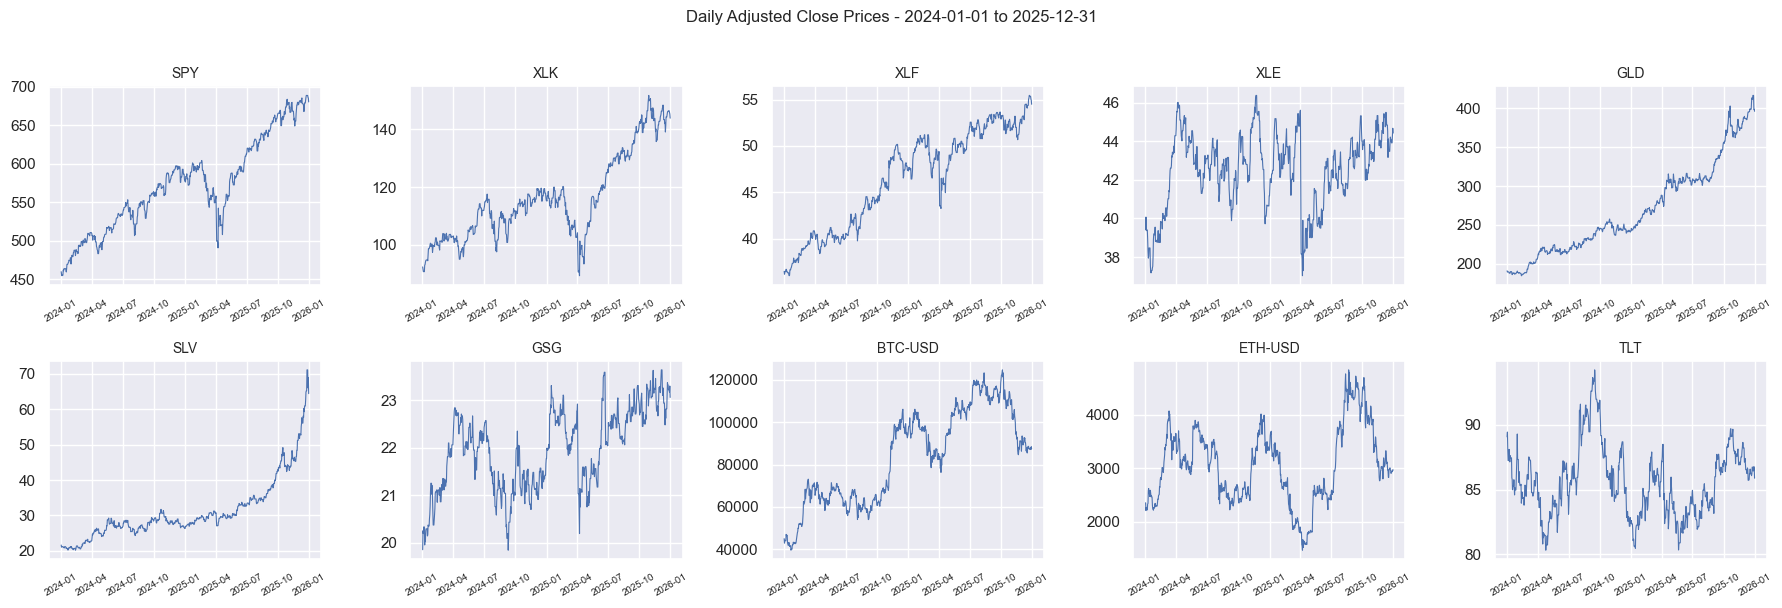

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=False)
axes = axes.flatten()
for i, col in enumerate(ASSETS):
    axes[i].plot(prices_clean.index, prices_clean[col], lw=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)

plt.suptitle(f"Daily Adjusted Close Prices - {START_DATE} to {END_DATE}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 1.2 Returns, EWMA Volatility, Pairwise Granger Tables, and Networks

In [5]:
ALPHA = 0.05
MAX_LAG = 5
EWMA_LAMBDA = 0.94


def resample_price_panel(price_panel, freq):
    """Last available price in each weekly/monthly period, clipped to the assigned epoch."""
    sampled = price_panel.resample(freq).last().ffill().dropna(how="any")
    return sampled.loc[:pd.Timestamp(END_DATE)]


def log_returns(price_panel):
    return np.log(price_panel).diff().dropna(how="any")


def ewma_volatility(return_panel, lambda_=EWMA_LAMBDA):
    """EWMA volatility sqrt(EWMA(r^2)); lambda=0.94 follows the usual RiskMetrics/Lab setup."""
    return return_panel.pow(2).ewm(alpha=1 - lambda_, adjust=False).mean().pow(0.5).dropna(how="any")


def _select_aic_lag(pair_data, max_lag=MAX_LAG):
    """Select an AIC lag in [1, max_lag] for one asset pair using VAR.select_order."""
    pair_data = pair_data.dropna()
    if pair_data.shape[0] < 8 or pair_data.nunique().min() <= 1:
        return None

    feasible_max = min(max_lag, max(1, (pair_data.shape[0] - 1) // 4))
    for trial_max in range(feasible_max, 0, -1):
        try:
            selected = VAR(pair_data).select_order(maxlags=trial_max, trend="n").selected_orders.get("aic")
            if selected is None or pd.isna(selected):
                selected = 1
            return int(min(max(int(selected), 1), trial_max))
        except Exception:
            continue
    return None


def _granger_pvalue(pair_data, lag):
    """Statsmodels tests whether column 2 Granger-causes column 1."""
    try:
        result = grangercausalitytests(pair_data, maxlag=lag, verbose=False)
        return float(result[lag][0]["ssr_ftest"][1])
    except Exception:
        return np.nan


def build_causality_table(series_panel, assets=ASSETS, alpha=ALPHA, max_lag=MAX_LAG):
    """
    Return row-to-column lag and p-value matrices.
    Entry lag_table.loc[cause, effect] = selected lag if cause -> effect is significant, else 0.
    """
    lag_table = pd.DataFrame(0, index=assets, columns=assets, dtype=int)
    pvalue_table = pd.DataFrame(np.nan, index=assets, columns=assets, dtype=float)
    selected_lag_table = pd.DataFrame(np.nan, index=assets, columns=assets, dtype=float)

    for cause in assets:
        for effect in assets:
            if cause == effect:
                continue
            pair = series_panel[[effect, cause]].replace([np.inf, -np.inf], np.nan).dropna()
            lag = _select_aic_lag(pair, max_lag=max_lag)
            if lag is None:
                continue
            pvalue = _granger_pvalue(pair, lag)
            selected_lag_table.loc[cause, effect] = lag
            pvalue_table.loc[cause, effect] = pvalue
            if np.isfinite(pvalue) and pvalue < alpha:
                lag_table.loc[cause, effect] = lag

    return lag_table, pvalue_table, selected_lag_table


def display_lag_table(lag_table, title):
    table = lag_table.astype(object).copy()
    for asset in table.index:
        table.loc[asset, asset] = "-"
    print(f"\n{title}")
    print(tabulate(table, headers="keys", tablefmt="rounded_outline"))


def network_summary(lag_table):
    adjacency = lag_table.fillna(0).astype(int)
    graph = nx.from_pandas_adjacency(adjacency, create_using=nx.DiGraph)
    rows = []
    for node in adjacency.index:
        rows.append({
            "asset": node,
            "out_degree": graph.out_degree(node),
            "in_degree": graph.in_degree(node),
        })
    return pd.DataFrame(rows).sort_values(["out_degree", "in_degree"], ascending=[False, False])


def plot_causality_network(lag_table, title):
    adjacency = lag_table.fillna(0).astype(int)
    graph = nx.from_pandas_adjacency(adjacency, create_using=nx.DiGraph)
    graph.remove_edges_from([(u, v) for u, v, d in graph.edges(data=True) if d.get("weight", 0) == 0])

    fig, ax = plt.subplots(figsize=(8, 7))
    if graph.number_of_edges() == 0:
        ax.text(0.5, 0.5, "No significant causal edges at 5%", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        ax.set_axis_off()
        plt.show()
        return graph

    pos = nx.spring_layout(graph, seed=42, k=1.2)
    out_degrees = dict(graph.out_degree())
    node_sizes = [900 + 220 * out_degrees.get(node, 0) for node in graph.nodes]
    node_colors = [out_degrees.get(node, 0) for node in graph.nodes]

    nx.draw_networkx_nodes(
        graph, pos, node_size=node_sizes, node_color=node_colors,
        cmap="viridis", edgecolors="white", linewidths=1.2, ax=ax,
    )
    nx.draw_networkx_labels(graph, pos, font_size=9, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(
        graph, pos, arrows=True, arrowsize=18, width=1.4,
        connectionstyle="arc3,rad=0.12", edge_color="0.35", ax=ax,
    )
    edge_labels = {(u, v): int(adjacency.loc[u, v]) for u, v in graph.edges}
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    return graph


def strongest_abs_correlations(panel, n=12):
    corr = panel.corr()
    pairs = []
    for i, left in enumerate(corr.columns):
        for right in corr.columns[i + 1:]:
            pairs.append({"pair": f"{left} - {right}", "corr": corr.loc[left, right], "abs_corr": abs(corr.loc[left, right])})
    return pd.DataFrame(pairs).sort_values("abs_corr", ascending=False).head(n).drop(columns="abs_corr")


In [6]:
weekly_prices = resample_price_panel(prices_clean, "W-FRI")
monthly_prices = resample_price_panel(prices_clean, "ME")

weekly_returns = log_returns(weekly_prices)
monthly_returns = log_returns(monthly_prices)
weekly_ewma_vol = ewma_volatility(weekly_returns)
monthly_ewma_vol = ewma_volatility(monthly_returns)

print("Panel sizes used for Granger tests:")
print(tabulate(pd.DataFrame({
    "series": ["weekly_returns", "monthly_returns", "weekly_ewma_vol", "monthly_ewma_vol"],
    "rows": [len(weekly_returns), len(monthly_returns), len(weekly_ewma_vol), len(monthly_ewma_vol)],
    "start": [weekly_returns.index.min().date(), monthly_returns.index.min().date(), weekly_ewma_vol.index.min().date(), monthly_ewma_vol.index.min().date()],
    "end": [weekly_returns.index.max().date(), monthly_returns.index.max().date(), weekly_ewma_vol.index.max().date(), monthly_ewma_vol.index.max().date()],
}), headers="keys", tablefmt="rounded_outline", showindex=False))

q1_panels = {
    "Weekly returns": weekly_returns,
    "Monthly returns": monthly_returns,
    "Weekly EWMA volatility": weekly_ewma_vol,
    "Monthly EWMA volatility": monthly_ewma_vol,
}

q1_results = {}
for label, panel in q1_panels.items():
    lag_table, pvalue_table, selected_lag_table = build_causality_table(panel)
    q1_results[label] = {
        "panel": panel,
        "lag_table": lag_table,
        "pvalue_table": pvalue_table,
        "selected_lag_table": selected_lag_table,
    }
    display_lag_table(lag_table, f"{label}: significant Granger causality lags (alpha={ALPHA})")


Panel sizes used for Granger tests:
╭──────────────────┬────────┬────────────┬────────────╮
│ series           │   rows │ start      │ end        │
├──────────────────┼────────┼────────────┼────────────┤
│ weekly_returns   │    103 │ 2024-01-12 │ 2025-12-26 │
│ monthly_returns  │     23 │ 2024-02-29 │ 2025-12-31 │
│ weekly_ewma_vol  │    103 │ 2024-01-12 │ 2025-12-26 │
│ monthly_ewma_vol │     23 │ 2024-02-29 │ 2025-12-31 │
╰──────────────────┴────────┴────────────┴────────────╯

Weekly returns: significant Granger causality lags (alpha=0.05)
╭─────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────────┬───────────┬───────╮
│         │ SPY   │ XLK   │ XLF   │ XLE   │ GLD   │ SLV   │ GSG   │ BTC-USD   │ ETH-USD   │ TLT   │
├─────────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────────┼───────────┼───────┤
│ SPY     │ -     │ 0     │ 0     │ 0     │ 0     │ 0     │ 0     │ 0         │ 0         │ 0     │
│ XLK     │ 0     │ -     │ 0     │ 0     │ 0     │


Strongest contemporaneous absolute correlations - Weekly returns
╭───────────────────┬────────╮
│ pair              │   corr │
├───────────────────┼────────┤
│ SPY - XLK         │  0.929 │
│ SPY - XLF         │  0.766 │
│ BTC-USD - ETH-USD │  0.733 │
│ GLD - SLV         │  0.68  │
│ XLE - GSG         │  0.636 │
│ XLF - XLE         │  0.581 │
│ XLK - XLF         │  0.548 │
│ SPY - XLE         │  0.438 │
│ SLV - GSG         │  0.349 │
│ GSG - TLT         │ -0.347 │
│ SPY - ETH-USD     │  0.321 │
│ XLK - GSG         │  0.31  │
╰───────────────────┴────────╯

Strongest contemporaneous absolute correlations - Monthly returns
╭───────────────────┬────────╮
│ pair              │   corr │
├───────────────────┼────────┤
│ SPY - XLK         │  0.841 │
│ BTC-USD - ETH-USD │  0.792 │
│ SPY - XLF         │  0.665 │
│ SPY - ETH-USD     │  0.657 │
│ XLF - XLE         │  0.588 │
│ XLE - GSG         │  0.554 │
│ XLK - ETH-USD     │  0.551 │
│ SPY - BTC-USD     │  0.549 │
│ GLD - SLV         │  0.512 │

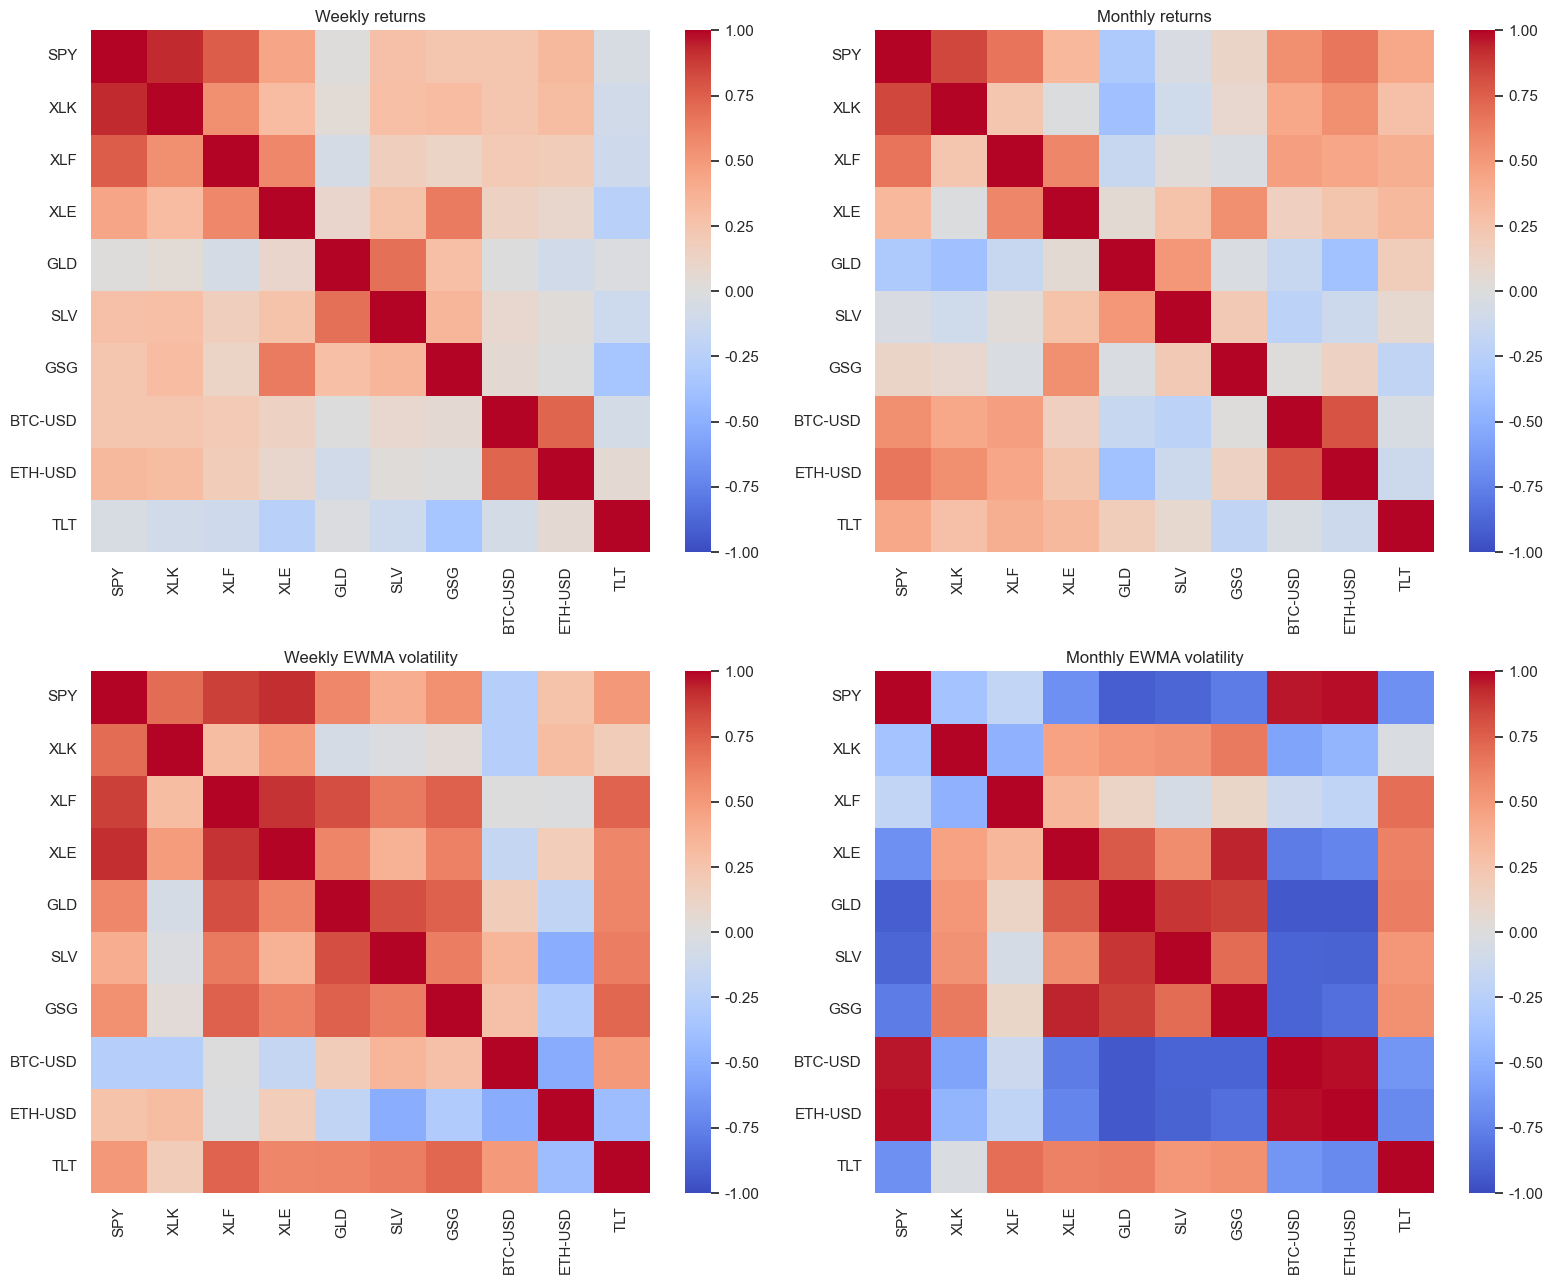

In [7]:
for label, result in q1_results.items():
    print(f"\nStrongest contemporaneous absolute correlations - {label}")
    print(tabulate(strongest_abs_correlations(result["panel"]).round(3), headers="keys", tablefmt="rounded_outline", showindex=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()
for ax, (label, result) in zip(axes, q1_results.items()):
    sns.heatmap(result["panel"].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(label)
plt.tight_layout()
plt.show()



Network summary - Weekly returns
╭─────────┬──────────────┬─────────────╮
│ asset   │   out_degree │   in_degree │
├─────────┼──────────────┼─────────────┤
│ ETH-USD │            2 │           0 │
│ TLT     │            1 │           1 │
│ GSG     │            1 │           0 │
│ GLD     │            0 │           2 │
│ XLK     │            0 │           1 │
│ SPY     │            0 │           0 │
│ XLF     │            0 │           0 │
│ XLE     │            0 │           0 │
│ SLV     │            0 │           0 │
│ BTC-USD │            0 │           0 │
╰─────────┴──────────────┴─────────────╯


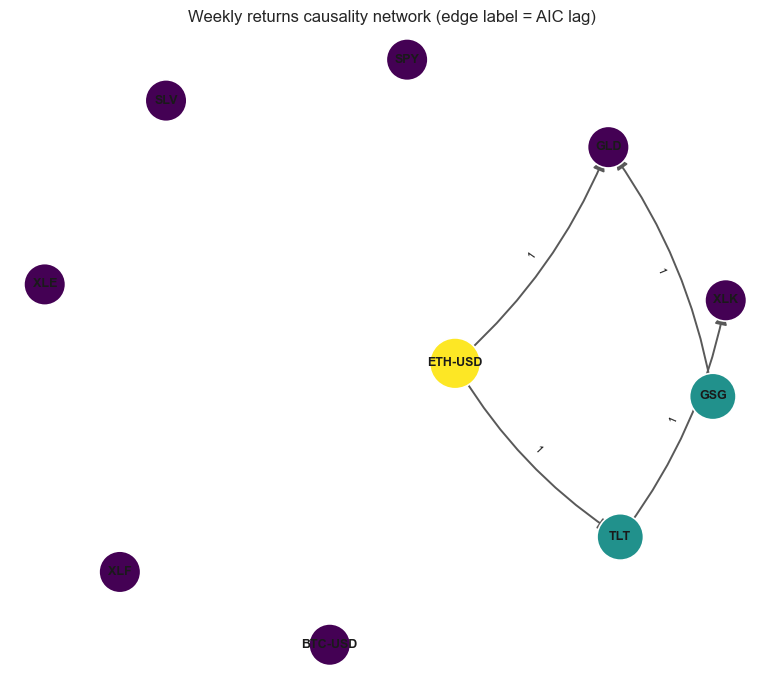


Network summary - Monthly returns
╭─────────┬──────────────┬─────────────╮
│ asset   │   out_degree │   in_degree │
├─────────┼──────────────┼─────────────┤
│ BTC-USD │            4 │           2 │
│ SPY     │            4 │           1 │
│ TLT     │            4 │           0 │
│ ETH-USD │            2 │           1 │
│ GSG     │            1 │           4 │
│ GLD     │            1 │           2 │
│ XLF     │            1 │           1 │
│ XLK     │            1 │           0 │
│ XLE     │            0 │           4 │
│ SLV     │            0 │           3 │
╰─────────┴──────────────┴─────────────╯


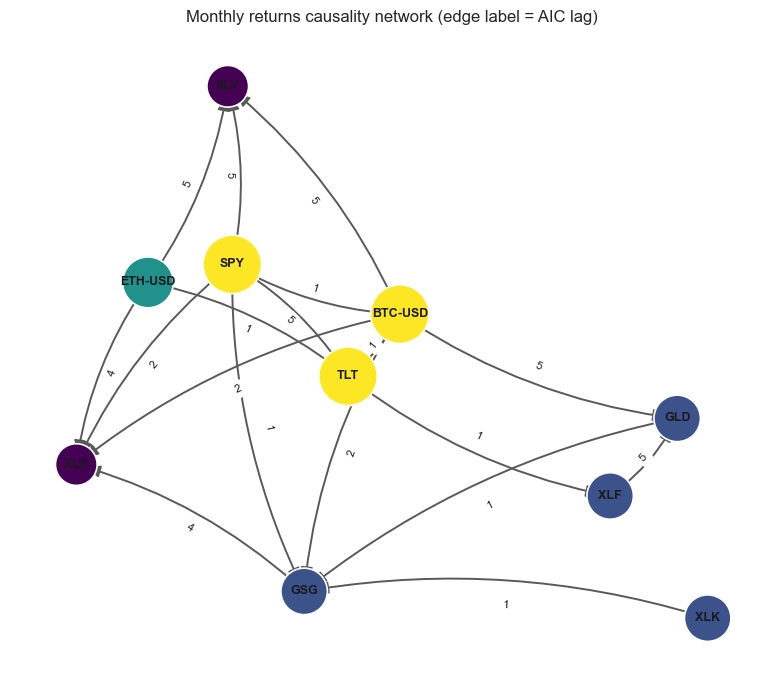


Network summary - Weekly EWMA volatility
╭─────────┬──────────────┬─────────────╮
│ asset   │   out_degree │   in_degree │
├─────────┼──────────────┼─────────────┤
│ XLF     │            5 │           0 │
│ SPY     │            4 │           1 │
│ XLE     │            4 │           0 │
│ XLK     │            3 │           0 │
│ GLD     │            1 │           5 │
│ GSG     │            1 │           4 │
│ BTC-USD │            1 │           4 │
│ SLV     │            1 │           0 │
│ TLT     │            0 │           6 │
│ ETH-USD │            0 │           0 │
╰─────────┴──────────────┴─────────────╯


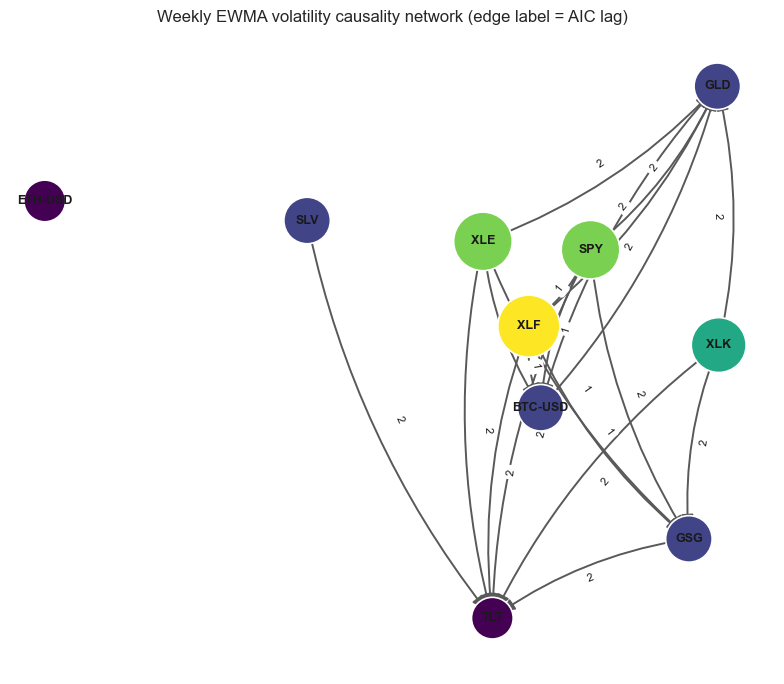


Network summary - Monthly EWMA volatility
╭─────────┬──────────────┬─────────────╮
│ asset   │   out_degree │   in_degree │
├─────────┼──────────────┼─────────────┤
│ SPY     │            3 │           2 │
│ XLK     │            3 │           1 │
│ TLT     │            3 │           1 │
│ XLE     │            2 │           2 │
│ BTC-USD │            2 │           0 │
│ XLF     │            1 │           2 │
│ SLV     │            1 │           0 │
│ GSG     │            0 │           4 │
│ GLD     │            0 │           2 │
│ ETH-USD │            0 │           1 │
╰─────────┴──────────────┴─────────────╯


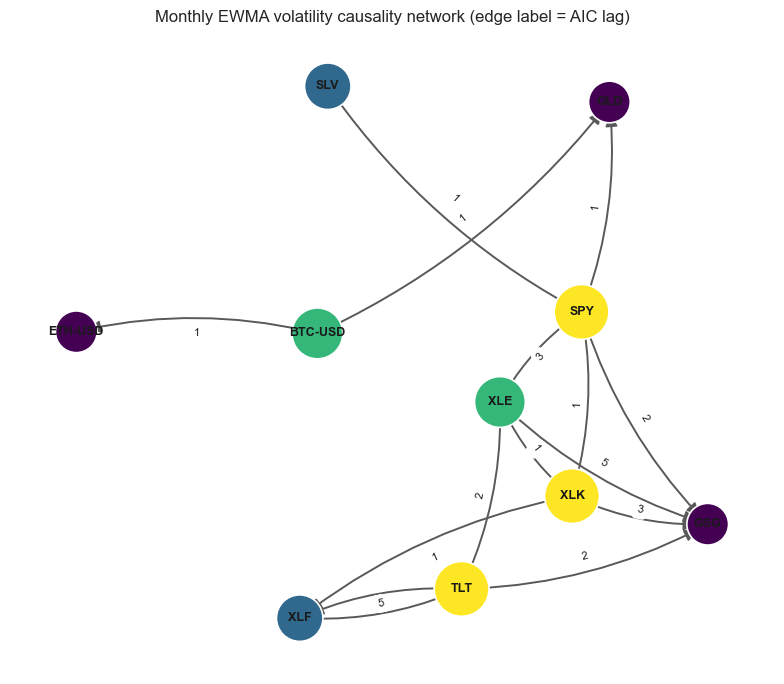

In [8]:
q1_graphs = {}
for label, result in q1_results.items():
    print(f"\nNetwork summary - {label}")
    summary = network_summary(result["lag_table"])
    print(tabulate(summary, headers="keys", tablefmt="rounded_outline", showindex=False))
    q1_graphs[label] = plot_causality_network(result["lag_table"], f"{label} causality network (edge label = AIC lag)")


### 1.3 Result Notes for the Report

After running the cells above, use the four causality tables and network summaries to write the report narrative:
- Returns network: assets with high out-degree are the main price-return drivers in this sample.
- Volatility network: assets with high out-degree are the main volatility or "fear" transmitters.
- Compare causal edges with the contemporaneous correlation lists; high same-period correlation is not the same as lagged Granger causality.
- Economic interpretation should be tied to the selected epoch. For example, crypto/technology links, commodity/energy links, or Treasury/equity links should be discussed only if they appear in the tables.


---
## 2. Problem 2: Neural Networks vs. LSTM vs. Gaussian Process

This section uses the assignment dataset `goyal-welch2022Monthly.csv` over 1927-2021. The main modeling target is the monthly S&P 500 log return, because the assignment asks for a Neural Network, LSTM, and Gaussian Process regression comparison and because price levels are non-stationary. Direction classification is kept as a secondary target comparison because the assignment allows it and it is economically interpretable.


### 2.1 Data Preparation — Goyal-Welch Predictors

In [3]:
GOYAL_CANDIDATES = [Path('../goyal-welch2022Monthly.csv'), Path('goyal-welch2022Monthly.csv')]
GOYAL_CSV = next((path for path in GOYAL_CANDIDATES if path.exists()), None)
if GOYAL_CSV is None:
    raise FileNotFoundError('Could not find goyal-welch2022Monthly.csv from the current notebook directory.')

gw_raw = pd.read_csv(GOYAL_CSV).rename(columns={'b/m': 'bm'})
gw_raw['Date'] = pd.to_datetime(gw_raw['yyyymm'].astype(str), format='%Y%m')

# The 2022 Goyal-Welch file stores some numbers, especially Index, with thousands separators.
for col in gw_raw.columns:
    if col not in ['yyyymm', 'Date']:
        gw_raw[col] = pd.to_numeric(gw_raw[col].astype(str).str.replace(',', '', regex=False), errors='coerce')

print(f"Raw shape: {gw_raw.shape} | date range: {gw_raw['Date'].min().date()} -> {gw_raw['Date'].max().date()}")

gw = (
    gw_raw[(gw_raw['Date'] >= '1927-01-01') & (gw_raw['Date'] <= '2021-12-31')]
    .copy()
    .sort_values('Date')
    .reset_index(drop=True)
)
print(f"Filtered shape: {gw.shape} | date range: {gw['Date'].min().date()} -> {gw['Date'].max().date()}")

# Return target and Goyal-Welch predictors.
gw['SP'] = np.log(gw['Index']) - np.log(gw['Index'].shift(1))
gw['direction'] = (gw['SP'] > 0).astype(int)
gw['dp'] = np.log(gw['D12']) - np.log(gw['Index'])
gw['ep'] = np.log(gw['E12']) - np.log(gw['Index'])
gw['de'] = np.log(gw['D12']) - np.log(gw['E12'])
gw['dy'] = np.log(gw['D12']) - np.log(gw['Index'].shift(1))
gw['dfy'] = gw['BAA'] - gw['AAA']

ASSIGNED_FEATURES = ['ep', 'svar', 'ntis']
ALL_GW_FEATURES = ['ep', 'svar', 'ntis', 'dp', 'de', 'dy', 'dfy', 'bm', 'tbl', 'infl']
TARGET_RETURN = 'SP'
TARGET_DIRECTION = 'direction'
LAGS = [1, 2, 3, 6, 12]
TRAIN_FRAC = 0.80
RANDOM_STATE = 42

gw_model = gw[['Date', 'Index', TARGET_RETURN, TARGET_DIRECTION] + ALL_GW_FEATURES].replace([np.inf, -np.inf], np.nan)
gw_model = gw_model.dropna(subset=[TARGET_RETURN] + ASSIGNED_FEATURES).copy()

print(f"Model dataframe: {gw_model.shape} ({gw_model['Date'].min().date()} -> {gw_model['Date'].max().date()})")

miss = gw_model[[TARGET_RETURN, TARGET_DIRECTION] + ALL_GW_FEATURES].isna().sum()
summary = pd.DataFrame({'Missing': miss, 'Pct %': (100 * miss / len(gw_model)).round(2)})
print('\nMissing values after transformations:')
print(tabulate(summary, headers='keys', tablefmt='rounded_outline'))

print('\nDirection class balance:')
class_balance = (100 * gw_model[TARGET_DIRECTION].value_counts(normalize=True).sort_index()).round(2)
class_balance.index = ['Down/flat', 'Up']
print(tabulate(class_balance.reset_index(name='Pct'), headers='keys', tablefmt='rounded_outline', showindex=False))

display(gw_model[[TARGET_RETURN] + ASSIGNED_FEATURES + ['dp', 'de', 'tbl', 'infl']].describe().round(4))


Raw shape: (1824, 19) | date range: 1871-01-01 -> 2022-12-01
Filtered shape: (1140, 19) | date range: 1927-01-01 -> 2021-12-01
Model dataframe: (1139, 14) (1927-02-01 -> 2021-12-01)

Missing values after transformations:
╭───────────┬───────────┬─────────╮
│           │   Missing │   Pct % │
├───────────┼───────────┼─────────┤
│ SP        │         0 │       0 │
│ direction │         0 │       0 │
│ ep        │         0 │       0 │
│ svar      │         0 │       0 │
│ ntis      │         0 │       0 │
│ dp        │         0 │       0 │
│ de        │         0 │       0 │
│ dy        │         0 │       0 │
│ dfy       │         0 │       0 │
│ bm        │         0 │       0 │
│ tbl       │         0 │       0 │
│ infl      │         0 │       0 │
╰───────────┴───────────┴─────────╯

Direction class balance:
╭───────────┬───────╮
│ index     │   Pct │
├───────────┼───────┤
│ Down/flat │ 40.47 │
│ Up        │ 59.53 │
╰───────────┴───────╯


,SP,ep,svar,ntis,dp,de,tbl,infl
count,1139.0000,1139.0000,1139.0000,1139.0000,1139.0000,1139.0000,1139.0000,1139.0000
mean,0.0052,-2.7590,0.0029,0.0161,-3.4022,-0.6433,0.0331,0.0024
std,0.0540,0.4215,0.0060,0.0257,0.4730,0.3265,0.0308,0.0052
min,-0.3559,-4.8365,0.0001,-0.0560,-4.5236,-1.2442,0.0001,-0.0205
25%,-0.0191,-2.9806,0.0007,0.0045,-3.8237,-0.8667,0.0038,0.0000
50%,0.0094,-2.8087,0.0013,0.0163,-3.3719,-0.6331,0.0278,0.0024
75%,0.0354,-2.4813,0.0025,0.0271,-3.0431,-0.5015,0.0509,0.0051
max,0.3522,-1.7750,0.0732,0.1770,-1.8732,1.3795,0.1630,0.0588


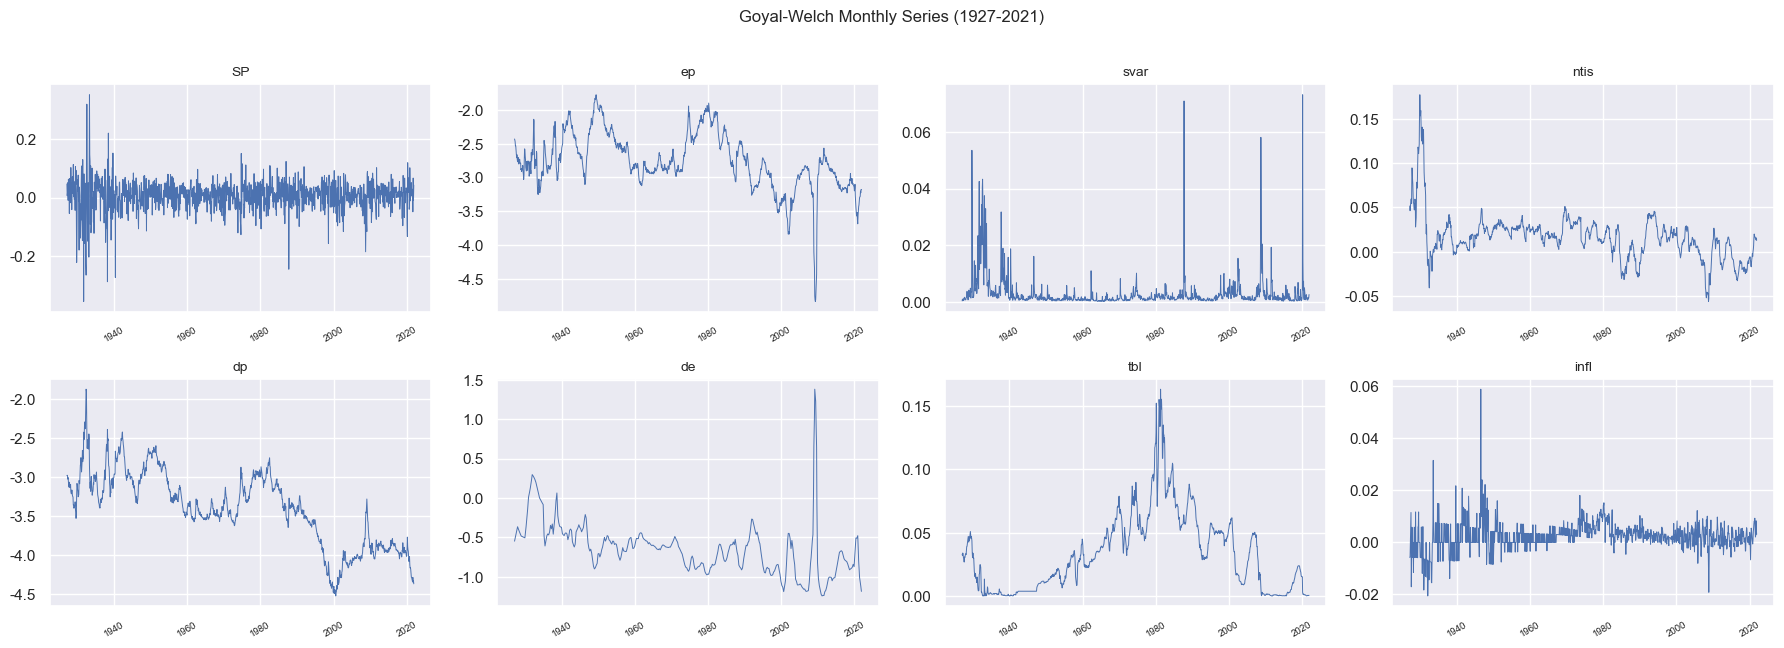

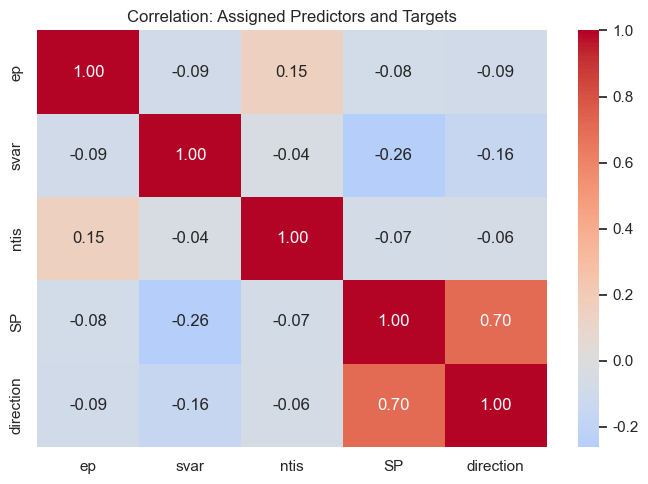

In [4]:
cols_to_plot = [TARGET_RETURN] + ASSIGNED_FEATURES + ['dp', 'de', 'tbl', 'infl']
n_cols = 4
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.2 * n_rows))
axes = np.asarray(axes).flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    ax.plot(gw_model['Date'], gw_model[col], lw=0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Goyal-Welch Monthly Series (1927-2021)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(gw_model[ASSIGNED_FEATURES + [TARGET_RETURN, TARGET_DIRECTION]].corr().round(2),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation: Assigned Predictors and Targets')
plt.tight_layout()
plt.show()


### 2.2 Target Choice Diagnostic

In [5]:
from statsmodels.tsa.stattools import adfuller

adf_rows = []
for label, series in {
    'Price level: Index': gw_model['Index'],
    'Monthly log return: SP': gw_model[TARGET_RETURN],
}.items():
    s = series.dropna()
    stat, pval, usedlag, nobs, *_ = adfuller(s, autolag='AIC')
    adf_rows.append({
        'series': label,
        'ADF statistic': stat,
        'p-value': pval,
        'used lag': usedlag,
        'nobs': nobs,
        'stationary at 5%?': 'yes' if pval < 0.05 else 'no',
    })

adf_table = pd.DataFrame(adf_rows)
display(adf_table.round({'ADF statistic': 4, 'p-value': 4}))
print('Price levels are not an appropriate main target because they are non-stationary. The return target is the main regression target; direction is kept as a secondary decision-oriented target.')


,series,ADF statistic,p-value,used lag,nobs,stationary at 5%?
0,Price level: Index,4.6941,1.0,23,1115,no
1,Monthly log return: SP,-7.9265,0.0,20,1118,yes


Price levels are not an appropriate main target because they are non-stationary. The return target is the main regression target; direction is kept as a secondary decision-oriented target.


### 2.2b Visual Target Diagnostics

The plots below support the target choice. Price levels are persistent and trend-dominated, so a model can look accurate by learning the level rather than forecasting economically meaningful movements. Monthly log returns are centered near a small mean with high volatility, which makes the historical mean a serious benchmark. Direction is useful as a secondary decision target, but class imbalance means raw accuracy must be interpreted with balanced metrics.

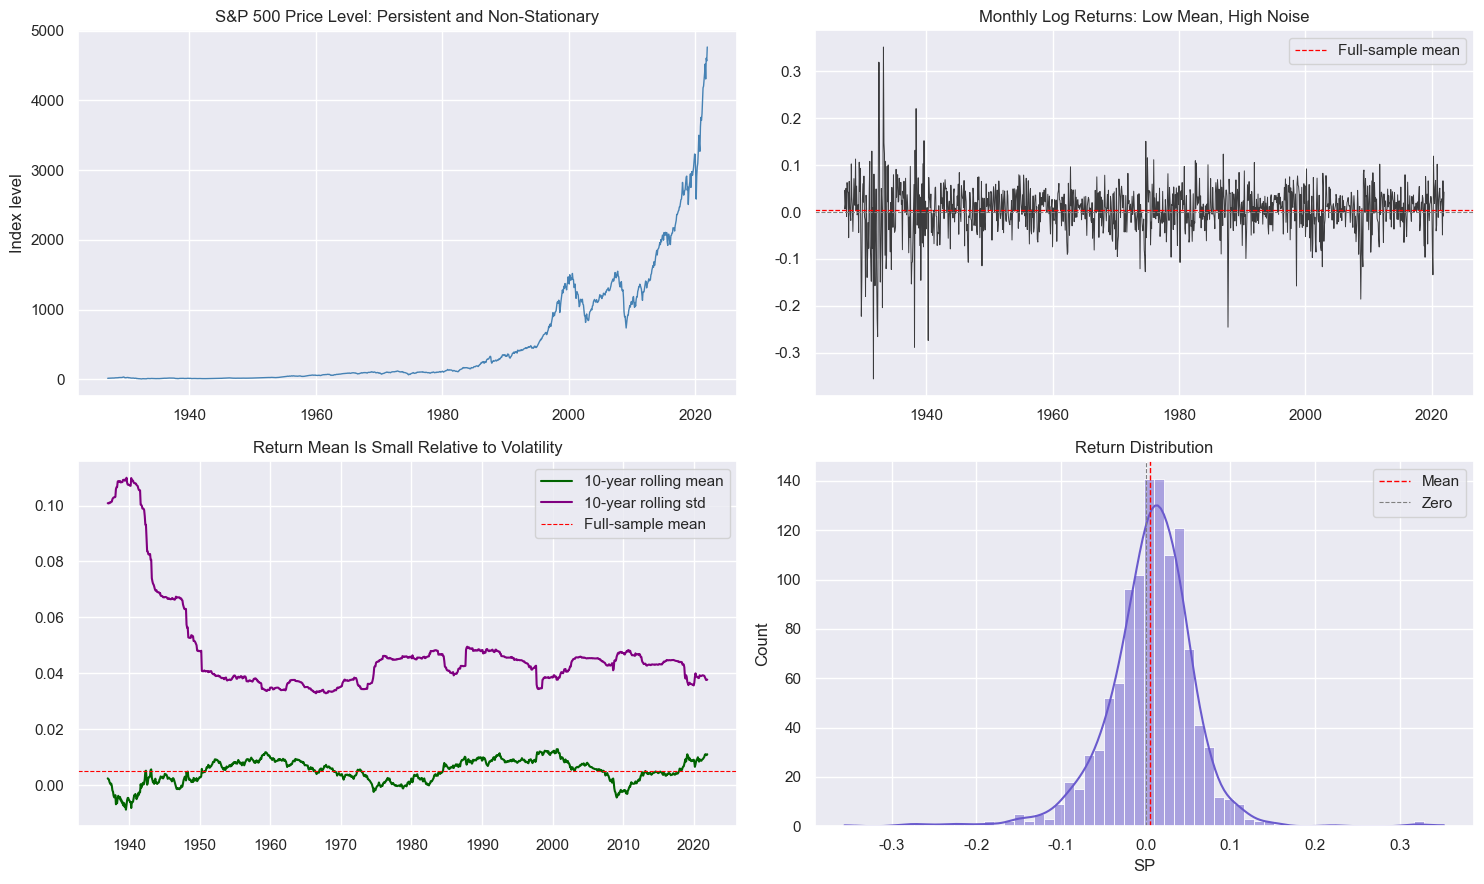

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(gw_model['Date'], gw_model['Index'], color='steelblue', lw=1.0)
axes[0, 0].set_title('S&P 500 Price Level: Persistent and Non-Stationary')
axes[0, 0].set_ylabel('Index level')

axes[0, 1].plot(gw_model['Date'], gw_model[TARGET_RETURN], color='black', lw=0.7, alpha=0.75)
axes[0, 1].axhline(0, color='gray', linestyle='--', lw=0.8)
axes[0, 1].axhline(gw_model[TARGET_RETURN].mean(), color='red', linestyle='--', lw=0.9, label='Full-sample mean')
axes[0, 1].set_title('Monthly Log Returns: Low Mean, High Noise')
axes[0, 1].legend()

rolling_window = 120
rolling_mean = gw_model[TARGET_RETURN].rolling(rolling_window).mean()
rolling_std = gw_model[TARGET_RETURN].rolling(rolling_window).std()
axes[1, 0].plot(gw_model['Date'], rolling_mean, label='10-year rolling mean', color='darkgreen')
axes[1, 0].plot(gw_model['Date'], rolling_std, label='10-year rolling std', color='purple')
axes[1, 0].axhline(gw_model[TARGET_RETURN].mean(), color='red', linestyle='--', lw=0.8, label='Full-sample mean')
axes[1, 0].set_title('Return Mean Is Small Relative to Volatility')
axes[1, 0].legend()

sns.histplot(gw_model[TARGET_RETURN], bins=60, kde=True, ax=axes[1, 1], color='slateblue')
axes[1, 1].axvline(gw_model[TARGET_RETURN].mean(), color='red', linestyle='--', lw=1.0, label='Mean')
axes[1, 1].axvline(0, color='gray', linestyle='--', lw=0.8, label='Zero')
axes[1, 1].set_title('Return Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### 2.3 Supervised Panels, Benchmarks, and Feature Selection

Return train period: 1928-02-01 -> 2003-02-01 (901 months)
Return test period : 2003-03-01 -> 2021-12-01 (226 months)
Candidate return features: 20


,MSE,RMSE,MAE,R2,Outperform mean %,Sign accuracy %
model,,,,,,
Historical mean return,0.001711,0.04136,0.030341,-0.006728,0.0,66.814159


Selected parsimonious feature set: ['ntis_lag1', 'ep_lag3', 'ntis_lag2', 'svar_lag3', 'ep_lag12', 'ntis_lag3']
Selected robust feature set: ['ntis_lag1', 'ep_lag3', 'ntis_lag2', 'svar_lag3', 'ep_lag12', 'ntis_lag3', 'TARGET_lag6', 'TARGET_lag12', 'ntis_lag6', 'TARGET_lag2']


,feature,importance
0,ntis_lag1,2.975400e-04
1,ep_lag3,1.414000e-04
2,ntis_lag2,8.044000e-05
3,svar_lag3,6.629000e-05
4,ep_lag12,4.099000e-05
5,ntis_lag3,3.935000e-05
6,TARGET_lag6,1.551000e-05
7,TARGET_lag12,1.285000e-05
8,ntis_lag6,1.089000e-05
9,TARGET_lag2,1.067000e-05


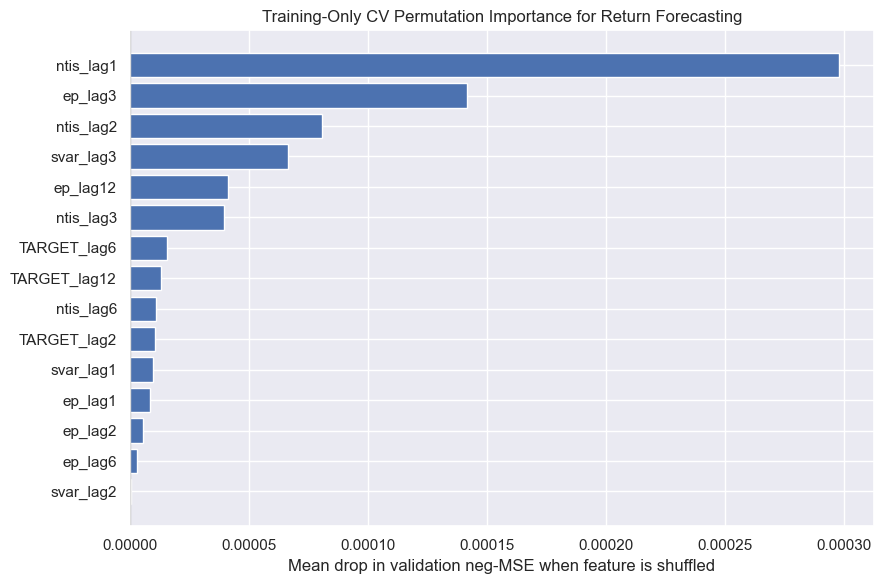

In [7]:
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


def make_supervised_panel(target='return', predictors=None, lags=None, train_frac=TRAIN_FRAC):
    """Create a one-step-ahead panel: row t uses only variables lagged before target t."""
    if predictors is None:
        predictors = ASSIGNED_FEATURES
    if lags is None:
        lags = LAGS

    target_col = TARGET_RETURN if target == 'return' else TARGET_DIRECTION
    panel = gw_model[['Date', target_col] + list(dict.fromkeys(predictors))].copy()
    panel = panel.rename(columns={target_col: 'TARGET'})

    for lag in lags:
        panel[f'TARGET_lag{lag}'] = panel['TARGET'].shift(lag)
    for var in predictors:
        for lag in lags:
            panel[f'{var}_lag{lag}'] = panel[var].shift(lag)

    panel = panel.drop(columns=list(predictors), errors='ignore').replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    feature_cols = [c for c in panel.columns if c not in ['Date', 'TARGET']]
    split_idx = int(train_frac * len(panel))

    train = panel.iloc[:split_idx].copy()
    test = panel.iloc[split_idx:].copy()

    y_train = train['TARGET'].astype(int) if target == 'direction' else train['TARGET'].astype(float)
    y_test = test['TARGET'].astype(int) if target == 'direction' else test['TARGET'].astype(float)

    return {
        'panel': panel,
        'train': train,
        'test': test,
        'X_train_all': train[feature_cols],
        'X_test_all': test[feature_cols],
        'y_train': y_train,
        'y_test': y_test,
        'feature_cols': feature_cols,
        'target': target,
    }


def regression_metrics(name, y_true, y_pred, train_mean):
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    mse_mean = mean_squared_error(y_true, np.repeat(train_mean, len(y_true)))
    return {
        'model': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'Outperform mean %': 100 * (1 - mse / mse_mean),
        'Sign accuracy %': 100 * accuracy_score((np.asarray(y_true) > 0).astype(int), (y_pred > 0).astype(int)),
    }


def classification_metrics(name, y_true, score, threshold=0.5):
    score = np.asarray(score).reshape(-1)
    y_pred = (score >= threshold).astype(int)
    row = {
        'model': name,
        'Accuracy %': 100 * accuracy_score(y_true, y_pred),
        'Balanced accuracy %': 100 * balanced_accuracy_score(y_true, y_pred),
        'Precision %': 100 * precision_score(y_true, y_pred, zero_division=0),
        'Recall %': 100 * recall_score(y_true, y_pred, zero_division=0),
        'F1 %': 100 * f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC %': 100 * roc_auc_score(y_true, score) if len(np.unique(score)) > 1 else np.nan,
    }
    return row, y_pred


def estimator_scores(estimator, X):
    if hasattr(estimator, 'predict_proba'):
        return estimator.predict_proba(X)[:, 1]
    return np.asarray(estimator.predict(X)).reshape(-1)


def cv_permutation_feature_selection(data, top_k=6, n_splits=5):
    """Training-only nonlinear feature screening using expanding-window permutation importance."""
    X_train = data['X_train_all']
    y_train = data['y_train']
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_importances = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        fs_model = GradientBoostingRegressor(
            n_estimators=100,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            random_state=RANDOM_STATE,
        )
        fs_model.fit(X_tr, y_tr)
        perm = permutation_importance(
            fs_model,
            X_val,
            y_val,
            n_repeats=5,
            random_state=RANDOM_STATE,
            scoring='neg_mean_squared_error',
        )
        fold_importances.append(perm.importances_mean)

    mean_importance = np.mean(fold_importances, axis=0)
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': mean_importance,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    selected = importance.head(top_k)['feature'].tolist()
    positive = importance[importance['importance'] > 0]['feature'].tolist()
    robust = positive[:max(top_k, min(10, len(positive)))] if positive else selected
    return importance, selected, robust

return_data = make_supervised_panel(target='return', predictors=ASSIGNED_FEATURES)

print(f"Return train period: {return_data['train']['Date'].min().date()} -> {return_data['train']['Date'].max().date()} ({len(return_data['train'])} months)")
print(f"Return test period : {return_data['test']['Date'].min().date()} -> {return_data['test']['Date'].max().date()} ({len(return_data['test'])} months)")
print(f"Candidate return features: {len(return_data['feature_cols'])}")

mean_benchmark_pred = np.repeat(return_data['y_train'].mean(), len(return_data['y_test']))
mean_benchmark = regression_metrics('Historical mean return', return_data['y_test'], mean_benchmark_pred, return_data['y_train'].mean())
display(pd.DataFrame([mean_benchmark]).set_index('model').round(6))

feature_importance, selected_top6, selected_robust = cv_permutation_feature_selection(return_data, top_k=6, n_splits=5)
print('Selected parsimonious feature set:', selected_top6)
print('Selected robust feature set:', selected_robust)
display(feature_importance.head(20).round(8))

fig, ax = plt.subplots(figsize=(9, 6))
plot_imp = feature_importance.sort_values('importance').tail(15)
ax.barh(plot_imp['feature'], plot_imp['importance'])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Training-Only CV Permutation Importance for Return Forecasting')
ax.set_xlabel('Mean drop in validation neg-MSE when feature is shuffled')
plt.tight_layout()
plt.show()

feature_sets = {
    'All assigned lags': return_data['feature_cols'],
    'Selected top 6': selected_top6,
    'Selected robust': selected_robust,
}


### 2.3b Modeling and Hyperparameter Rationale

The model grids are intentionally modest. Monthly return forecasting has a low signal-to-noise ratio, so highly flexible specifications are more likely to fit noise than stable predictability. The grids below are designed to satisfy the assignment's tuning requirement while keeping the comparison defensible and leakage-safe.

In [8]:
rationale_table = pd.DataFrame([
    {
        'Component': 'Lag grid',
        'Choice': '1, 2, 3, 6, 12 months',
        'Why this is defensible': 'Combines short-run dynamics with quarterly, half-year, and annual macro effects.',
        'Overfitting control': 'Small fixed grid, applied equally to target lags and assigned predictor lags.',
    },
    {
        'Component': 'Feature selection',
        'Choice': 'Training-only CV permutation importance',
        'Why this is defensible': 'Allows nonlinear screens while avoiding test-set feedback.',
        'Overfitting control': 'Expanding-window validation and parsimonious/robust feature sets.',
    },
    {
        'Component': 'MLPRegressor',
        'Choice': 'Small/deep-narrow networks, tanh/relu, high L2, scaled target',
        'Why this is defensible': 'Monthly returns are tiny in magnitude; target scaling helps optimization and L2 discourages noise fitting.',
        'Overfitting control': 'TimeSeriesSplit tuning and conservative layer sizes.',
    },
    {
        'Component': 'GaussianProcessRegressor',
        'Choice': 'RBF, Matern, RationalQuadratic, WhiteKernel/alpha noise control',
        'Why this is defensible': 'Kernels encode smooth nonlinear relationships; noise terms acknowledge large unpredictable return component.',
        'Overfitting control': 'Compare explicit white noise with alpha regularization; normalize_y=True.',
    },
    {
        'Component': 'LSTMRegressor',
        'Choice': 'Lookbacks 3 and 12, small units, dropout, L2, early stopping',
        'Why this is defensible': 'Tests whether a short or annual sequence of macro states helps returns.',
        'Overfitting control': 'Small architecture, chronological validation, dropout, and early stopping.',
    },
    {
        'Component': 'Benchmarks',
        'Choice': 'Historical mean for returns; majority and previous direction for classification',
        'Why this is defensible': 'Simple baselines are hard to beat in efficient monthly equity returns.',
        'Overfitting control': 'Models must improve out of sample, not only in training/CV.',
    },
])
display(rationale_table)


,Component,Choice,Why this is defensible,Overfitting control
0,Lag grid,"1, 2, 3, 6, 12 months","Combines short-run dynamics with quarterly, ha...","Small fixed grid, applied equally to target la..."
1,Feature selection,Training-only CV permutation importance,Allows nonlinear screens while avoiding test-s...,Expanding-window validation and parsimonious/r...
2,MLPRegressor,"Small/deep-narrow networks, tanh/relu, high L2...",Monthly returns are tiny in magnitude; target ...,TimeSeriesSplit tuning and conservative layer ...
3,GaussianProcessRegressor,"RBF, Matern, RationalQuadratic, WhiteKernel/al...",Kernels encode smooth nonlinear relationships;...,Compare explicit white noise with alpha regula...
4,LSTMRegressor,"Lookbacks 3 and 12, small units, dropout, L2, ...",Tests whether a short or annual sequence of ma...,"Small architecture, chronological validation, ..."
5,Benchmarks,Historical mean for returns; majority and prev...,Simple baselines are hard to beat in efficient...,"Models must improve out of sample, not only in..."


### 2.4 Neural Network Return Regression

In [9]:
tscv = TimeSeriesSplit(n_splits=3)
mlp_results = []
mlp_predictions = {}

mlp_grid = {
    'regressor__mlp__hidden_layer_sizes': [(8,), (16,), (8, 4)],
    'regressor__mlp__activation': ['relu', 'tanh'],
    'regressor__mlp__alpha': [0.1, 1.0, 5.0],
}

for fs_name, cols in feature_sets.items():
    X_train = return_data['X_train_all'][cols]
    X_test = return_data['X_test_all'][cols]
    y_train = return_data['y_train']
    y_test = return_data['y_test']

    mlp_est = TransformedTargetRegressor(
        regressor=Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPRegressor(solver='lbfgs', max_iter=1500, random_state=RANDOM_STATE)),
        ]),
        transformer=StandardScaler(),
    )
    search = GridSearchCV(
        mlp_est,
        param_grid=mlp_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    pred = search.predict(X_test)
    row = regression_metrics(f'MLPRegressor - {fs_name}', y_test, pred, y_train.mean())
    row['Best params'] = search.best_params_
    row['Feature count'] = len(cols)
    mlp_results.append(row)
    mlp_predictions[fs_name] = pred

mlp_table = pd.DataFrame(mlp_results).sort_values('Outperform mean %', ascending=False)
display(mlp_table.drop(columns=['Best params']).round(6))
for row in mlp_results:
    print(row['model'], row['Best params'])


,model,MSE,RMSE,MAE,R2,Outperform mean %,Sign accuracy %,Feature count
1,MLPRegressor - Selected top 6,0.004790,0.069208,0.056173,-1.818774,-179.993545,42.035398,6
2,MLPRegressor - Selected robust,0.007030,0.083842,0.051442,-3.136836,-310.918823,58.849558,10
0,MLPRegressor - All assigned lags,0.008016,0.089533,0.054890,-3.717453,-368.592468,43.805310,20


MLPRegressor - All assigned lags {'regressor__mlp__activation': 'relu', 'regressor__mlp__alpha': 5.0, 'regressor__mlp__hidden_layer_sizes': (16,)}
MLPRegressor - Selected top 6 {'regressor__mlp__activation': 'tanh', 'regressor__mlp__alpha': 1.0, 'regressor__mlp__hidden_layer_sizes': (8,)}
MLPRegressor - Selected robust {'regressor__mlp__activation': 'relu', 'regressor__mlp__alpha': 5.0, 'regressor__mlp__hidden_layer_sizes': (8, 4)}


### 2.5 Gaussian Process Return Regression

,model,MSE,RMSE,MAE,R2,Outperform mean %,Sign accuracy %,Feature count
0,GPRegressor - All assigned lags,0.001740,0.041719,0.031103,-0.024276,-1.743011,55.309735,20
2,GPRegressor - Selected robust,0.002002,0.044748,0.034195,-0.178401,-17.052500,49.115044,10
1,GPRegressor - Selected top 6,0.002319,0.048151,0.037192,-0.364458,-35.533910,52.654867,6


GPRegressor - All assigned lags {'gp__alpha': 0.1, 'gp__kernel': Matern(length_scale=1, nu=1.5)}
GPRegressor - Selected top 6 {'gp__alpha': 0.1, 'gp__kernel': Matern(length_scale=1, nu=1.5)}
GPRegressor - Selected robust {'gp__alpha': 0.1, 'gp__kernel': Matern(length_scale=1, nu=1.5)}


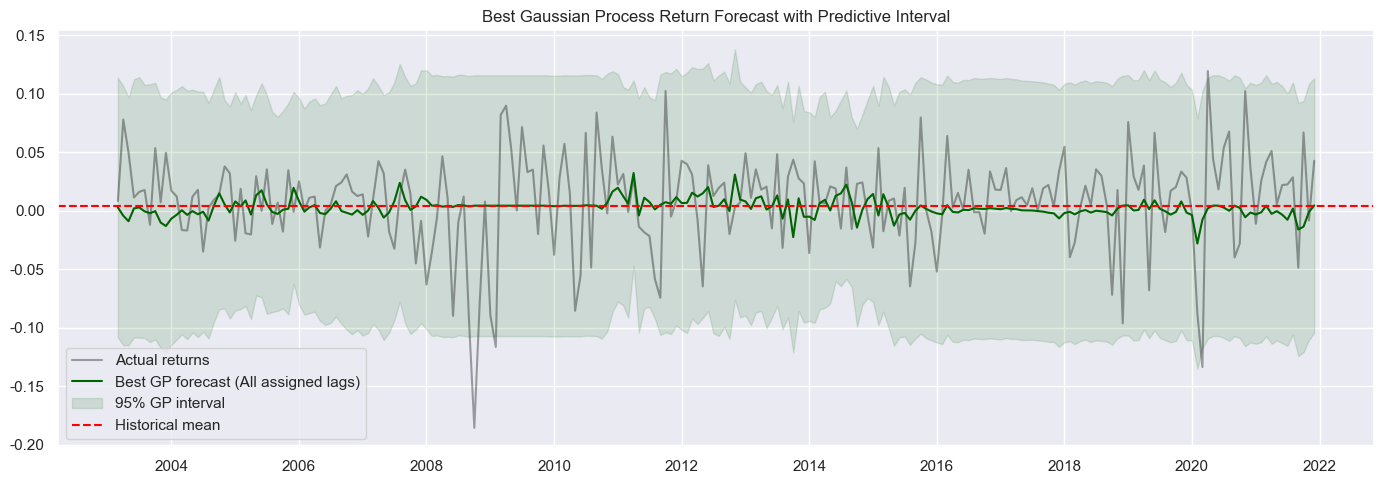

In [10]:
gp_results = []
gp_predictions = {}
gp_stds = {}

gp_grid = [
    {
        'gp__kernel': [RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1),
                       RationalQuadratic(length_scale=1.0, alpha=1.0) + WhiteKernel(noise_level=0.1)],
        'gp__alpha': [1e-6],
    },
    {
        'gp__kernel': [RBF(length_scale=1.0), Matern(length_scale=1.0, nu=1.5)],
        'gp__alpha': [1e-3, 1e-2, 1e-1],
    },
]

gp_best_estimators = {}
for fs_name, cols in feature_sets.items():
    X_train = return_data['X_train_all'][cols]
    X_test = return_data['X_test_all'][cols]
    y_train = return_data['y_train']
    y_test = return_data['y_test']

    gp_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('gp', GaussianProcessRegressor(normalize_y=True, optimizer=None, random_state=RANDOM_STATE)),
    ])
    search = GridSearchCV(
        gp_pipe,
        param_grid=gp_grid,
        cv=TimeSeriesSplit(n_splits=3),
        scoring='neg_mean_squared_error',
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    pred, std = search.best_estimator_.predict(X_test, return_std=True)
    row = regression_metrics(f'GPRegressor - {fs_name}', y_test, pred, y_train.mean())
    row['Best params'] = search.best_params_
    row['Feature count'] = len(cols)
    gp_results.append(row)
    gp_predictions[fs_name] = pred
    gp_stds[fs_name] = std
    gp_best_estimators[fs_name] = search.best_estimator_

gp_table = pd.DataFrame(gp_results).sort_values('Outperform mean %', ascending=False)
display(gp_table.drop(columns=['Best params']).round(6))
for row in gp_results:
    print(row['model'], row['Best params'])

best_gp_row = max(gp_results, key=lambda r: r['Outperform mean %'])
best_gp_name = best_gp_row['model'].replace('GPRegressor - ', '')
fig, ax = plt.subplots(figsize=(14, 5))
test_dates = return_data['test']['Date']
y_test = return_data['y_test']
y_pred = gp_predictions[best_gp_name]
y_std = gp_stds[best_gp_name]
ax.plot(test_dates, y_test, label='Actual returns', color='black', alpha=0.35)
ax.plot(test_dates, y_pred, label=f'Best GP forecast ({best_gp_name})', color='darkgreen')
ax.fill_between(test_dates, y_pred - 1.96 * y_std, y_pred + 1.96 * y_std, color='darkgreen', alpha=0.12, label='95% GP interval')
ax.axhline(return_data['y_train'].mean(), color='red', linestyle='--', label='Historical mean')
ax.set_title('Best Gaussian Process Return Forecast with Predictive Interval')
ax.legend()
plt.tight_layout()
plt.show()


### 2.6 LSTM Return Regression

In [11]:
from tensorflow.keras.regularizers import l2


def make_lstm_regression_sequences(X, y, timesteps):
    X_values = np.asarray(X, dtype=np.float32)
    y_values = np.asarray(y, dtype=np.float32).reshape(-1)
    X_seq, y_seq = [], []
    for i in range(timesteps, len(X_values)):
        X_seq.append(X_values[i - timesteps:i])
        y_seq.append(y_values[i])
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)


def fit_lstm_regressor(X_train_df, y_train_ser, X_test_df, y_test_ser, timesteps, units, layers, dropout):
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(X_train_df)
    X_test_scaled = x_scaler.transform(X_test_df)
    y_train_scaled = y_scaler.fit_transform(np.asarray(y_train_ser).reshape(-1, 1)).reshape(-1)

    X_seq, y_seq = make_lstm_regression_sequences(X_train_scaled, y_train_scaled, timesteps)
    X_test_seq, y_test_seq = make_lstm_regression_sequences(X_test_scaled, y_test_ser, timesteps)

    val_start = int(0.85 * len(X_seq))
    X_fit, y_fit = X_seq[:val_start], y_seq[:val_start]
    X_val, y_val = X_seq[val_start:], y_seq[val_start:]

    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential()
    if layers == 1:
        model.add(LSTM(units, input_shape=(timesteps, X_train_df.shape[1]),
                       dropout=dropout, recurrent_dropout=dropout,
                       kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-3)))
    else:
        model.add(LSTM(units, return_sequences=True, input_shape=(timesteps, X_train_df.shape[1]),
                       dropout=dropout, recurrent_dropout=dropout,
                       kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-3)))
        model.add(LSTM(units, dropout=dropout, recurrent_dropout=dropout,
                       kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-3)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    history = model.fit(
        X_fit, y_fit,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=16,
        shuffle=False,
        verbose=0,
        callbacks=[early_stop],
    )

    val_pred_scaled = model.predict(X_val, verbose=0).reshape(-1)
    val_mse = mean_squared_error(y_scaler.inverse_transform(y_val.reshape(-1, 1)).reshape(-1),
                                 y_scaler.inverse_transform(val_pred_scaled.reshape(-1, 1)).reshape(-1))
    test_pred_scaled = model.predict(X_test_seq, verbose=0).reshape(-1)
    test_pred = y_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).reshape(-1)

    return {
        'model': model,
        'history': history,
        'val_mse': val_mse,
        'test_pred': test_pred,
        'y_test_seq': y_test_seq,
        'config': {'timesteps': timesteps, 'units': units, 'layers': layers, 'dropout': dropout},
    }

lstm_configs = [
    {'timesteps': 3, 'units': 16, 'layers': 1, 'dropout': 0.2},
    {'timesteps': 12, 'units': 16, 'layers': 1, 'dropout': 0.2},
    {'timesteps': 12, 'units': 32, 'layers': 1, 'dropout': 0.2},
]

lstm_results = []
lstm_predictions = {}
for fs_name in ['Selected top 6', 'Selected robust']:
    cols = feature_sets[fs_name]
    X_train = return_data['X_train_all'][cols]
    X_test = return_data['X_test_all'][cols]
    y_train = return_data['y_train']
    y_test = return_data['y_test']

    runs = [fit_lstm_regressor(X_train, y_train, X_test, y_test, **cfg) for cfg in lstm_configs]
    best_run = min(runs, key=lambda r: r['val_mse'])
    row = regression_metrics(f'LSTMRegressor - {fs_name}', best_run['y_test_seq'], best_run['test_pred'], y_train.mean())
    row['Best params'] = best_run['config']
    row['Feature count'] = len(cols)
    row['Validation MSE'] = best_run['val_mse']
    lstm_results.append(row)
    lstm_predictions[fs_name] = best_run

lstm_table = pd.DataFrame(lstm_results).sort_values('Outperform mean %', ascending=False)
display(lstm_table.drop(columns=['Best params']).round(6))
for row in lstm_results:
    print(row['model'], row['Best params'])


,model,MSE,RMSE,MAE,R2,Outperform mean %,Sign accuracy %,Feature count,Validation MSE
1,LSTMRegressor - Selected robust,0.001853,0.043046,0.030665,-0.064290,-6.086511,64.018692,10,0.001929
0,LSTMRegressor - Selected top 6,0.001899,0.043582,0.032442,-0.090965,-8.745387,47.663551,6,0.001873


LSTMRegressor - Selected top 6 {'timesteps': 12, 'units': 32, 'layers': 1, 'dropout': 0.2}
LSTMRegressor - Selected robust {'timesteps': 12, 'units': 16, 'layers': 1, 'dropout': 0.2}


### 2.7 Return Forecast Leaderboard

,model,MSE,RMSE,MAE,R2,Outperform mean %,Sign accuracy %,Feature count,Validation MSE
0,Historical mean return,0.001711,0.041360,0.030341,-0.006728,0.000000,66.814159,NaN,NaN
4,GPRegressor - All assigned lags,0.001740,0.041719,0.031103,-0.024276,-1.743011,55.309735,20.0,NaN
8,LSTMRegressor - Selected robust,0.001853,0.043046,0.030665,-0.064290,-6.086511,64.018692,10.0,0.001929
7,LSTMRegressor - Selected top 6,0.001899,0.043582,0.032442,-0.090965,-8.745387,47.663551,6.0,0.001873
6,GPRegressor - Selected robust,0.002002,0.044748,0.034195,-0.178401,-17.052500,49.115044,10.0,NaN
5,GPRegressor - Selected top 6,0.002319,0.048151,0.037192,-0.364458,-35.533910,52.654867,6.0,NaN
2,MLPRegressor - Selected top 6,0.004790,0.069208,0.056173,-1.818774,-179.993545,42.035398,6.0,NaN
3,MLPRegressor - Selected robust,0.007030,0.083842,0.051442,-3.136836,-310.918823,58.849558,10.0,NaN
1,MLPRegressor - All assigned lags,0.008016,0.089533,0.054890,-3.717453,-368.592468,43.805310,20.0,NaN


Best return model: GPRegressor - All assigned lags


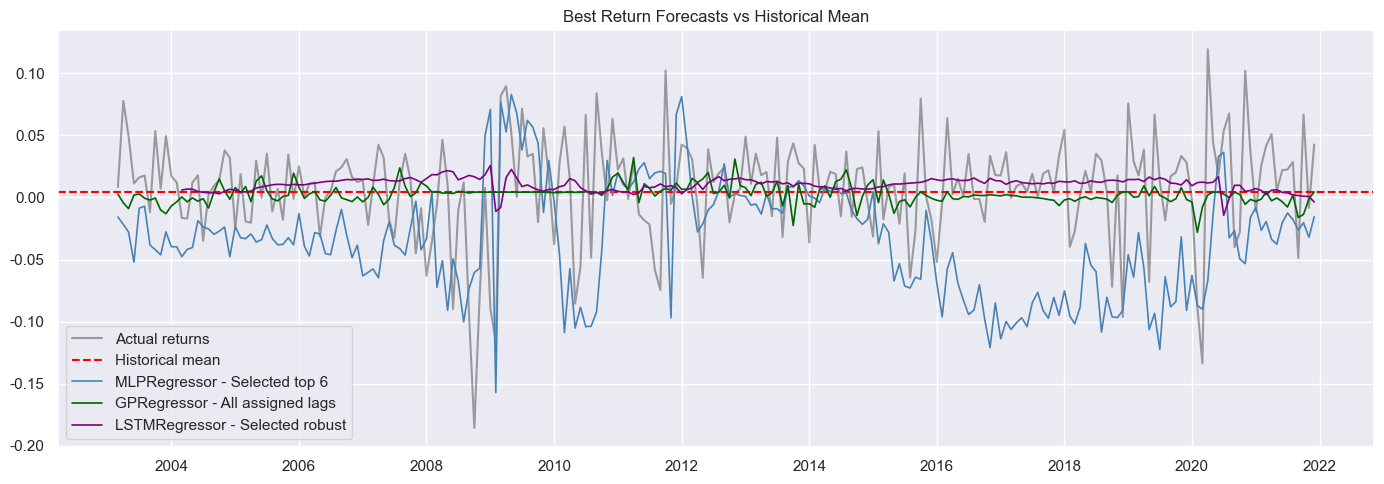

In [12]:
return_leaderboard = pd.DataFrame([mean_benchmark] + mlp_results + gp_results + lstm_results)
return_leaderboard = return_leaderboard.sort_values('Outperform mean %', ascending=False)
display(return_leaderboard.drop(columns=[c for c in ['Best params'] if c in return_leaderboard.columns]).round(6))

best_return = return_leaderboard[return_leaderboard['model'] != 'Historical mean return'].iloc[0]
print('Best return model:', best_return['model'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(return_data['test']['Date'], return_data['y_test'], label='Actual returns', color='black', alpha=0.35)
ax.axhline(return_data['y_train'].mean(), color='red', linestyle='--', label='Historical mean')

for row, predictions_dict, color in [
    (mlp_results, mlp_predictions, 'steelblue'),
    (gp_results, gp_predictions, 'darkgreen'),
]:
    if row:
        best_row = max(row, key=lambda r: r['Outperform mean %'])
        fs_name = best_row['model'].split(' - ', 1)[1]
        ax.plot(return_data['test']['Date'], predictions_dict[fs_name], label=best_row['model'], color=color, lw=1.2)

if lstm_results:
    best_lstm_row = max(lstm_results, key=lambda r: r['Outperform mean %'])
    fs_name = best_lstm_row['model'].split(' - ', 1)[1]
    lstm_dates = return_data['test']['Date'].iloc[lstm_predictions[fs_name]['config']['timesteps']:]
    ax.plot(lstm_dates, lstm_predictions[fs_name]['test_pred'], label=best_lstm_row['model'], color='purple', lw=1.2)

ax.set_title('Best Return Forecasts vs Historical Mean')
ax.legend()
plt.tight_layout()
plt.show()


### 2.7b Report Visuals for Model Comparison

These plots are designed for the report. They make the main result visually clear: the best model only marginally improves on the historical mean, while more flexible models can perform much worse. That supports the interpretation that return predictability is weak and that model complexity must be justified out of sample.

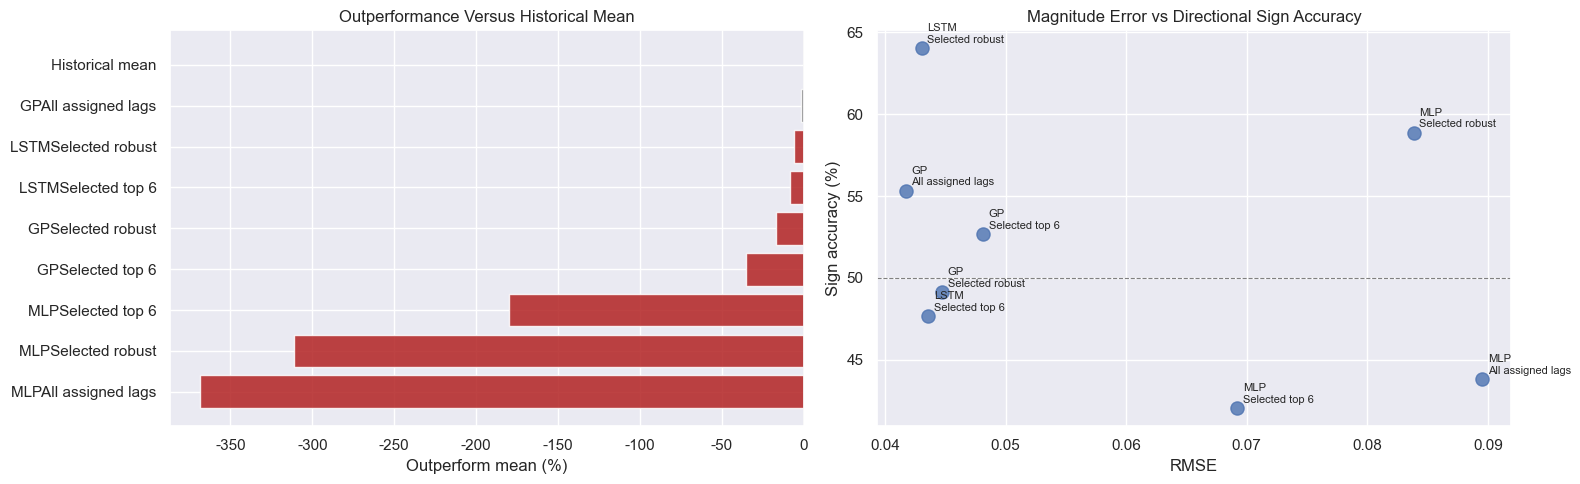

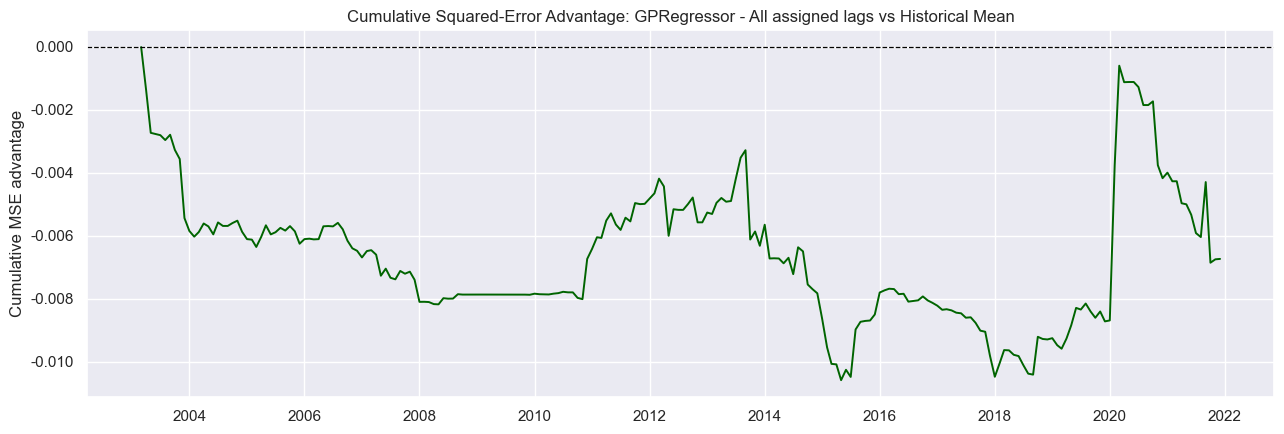

In [13]:
plot_lb = return_leaderboard.copy()
plot_lb['Short model'] = plot_lb['model'].str.replace('Regressor - ', '', regex=False).str.replace(' return', '', regex=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bar_data = plot_lb.sort_values('Outperform mean %')
colors = ['darkgreen' if x > 0 else 'firebrick' if x < -5 else 'gray' for x in bar_data['Outperform mean %']]
axes[0].barh(bar_data['Short model'], bar_data['Outperform mean %'], color=colors, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.9)
axes[0].set_title('Outperformance Versus Historical Mean')
axes[0].set_xlabel('Outperform mean (%)')

scatter_data = plot_lb[plot_lb['model'] != 'Historical mean return']
axes[1].scatter(scatter_data['RMSE'], scatter_data['Sign accuracy %'], s=90, alpha=0.8)
for _, row in scatter_data.iterrows():
    label = row['model'].replace('Regressor - ', '\n')
    axes[1].annotate(label, (row['RMSE'], row['Sign accuracy %']), fontsize=8, xytext=(4, 4), textcoords='offset points')
axes[1].axhline(50, color='gray', linestyle='--', lw=0.8)
axes[1].set_title('Magnitude Error vs Directional Sign Accuracy')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Sign accuracy (%)')

plt.tight_layout()
plt.show()

# Compare cumulative squared-error advantage of the best model versus the historical mean.
best_non_mean = return_leaderboard[return_leaderboard['model'] != 'Historical mean return'].iloc[0]
best_model_name = best_non_mean['model']

if best_model_name.startswith('LSTM'):
    best_fs = best_model_name.split(' - ', 1)[1]
    best_pred = lstm_predictions[best_fs]['test_pred']
    best_y = lstm_predictions[best_fs]['y_test_seq']
    best_dates = return_data['test']['Date'].iloc[lstm_predictions[best_fs]['config']['timesteps']:].reset_index(drop=True)
elif best_model_name.startswith('GP'):
    best_fs = best_model_name.split(' - ', 1)[1]
    best_pred = gp_predictions[best_fs]
    best_y = return_data['y_test'].to_numpy()
    best_dates = return_data['test']['Date'].reset_index(drop=True)
else:
    best_fs = best_model_name.split(' - ', 1)[1]
    best_pred = mlp_predictions[best_fs]
    best_y = return_data['y_test'].to_numpy()
    best_dates = return_data['test']['Date'].reset_index(drop=True)

mean_pred = np.repeat(return_data['y_train'].mean(), len(best_y))
model_sq_error = (np.asarray(best_y) - np.asarray(best_pred)) ** 2
mean_sq_error = (np.asarray(best_y) - mean_pred) ** 2
cum_improvement = np.cumsum(mean_sq_error - model_sq_error)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(best_dates, cum_improvement, color='darkgreen', lw=1.4)
ax.axhline(0, color='black', linestyle='--', lw=0.9)
ax.set_title(f'Cumulative Squared-Error Advantage: {best_model_name} vs Historical Mean')
ax.set_ylabel('Cumulative MSE advantage')
plt.tight_layout()
plt.show()


### 2.8 Secondary Target Check — Direction Classification

,Accuracy %,Balanced accuracy %,Precision %,Recall %,F1 %,ROC-AUC %
model,,,,,,
Previous-month direction,57.0796,51.7748,68.0000,67.5497,67.7741,51.7748
Direction MLPClassifier,50.8850,50.8300,67.5439,50.9934,58.1132,48.2472
Direction LSTMClassifier,64.9533,50.2799,65.5502,97.8571,78.5100,48.5907
Direction majority class,66.8142,50.0000,66.8142,100.0000,80.1061,NaN
Direction GaussianProcessClassifier,52.2124,45.1126,63.6943,66.2252,64.9351,43.7086


Best direction MLP params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (16, 8)}
Best direction GP params: {'gp__kernel': RBF(length_scale=1)}
Direction features: ['svar_lag12', 'svar_lag6', 'ntis_lag6', 'ntis_lag12', 'ntis_lag3', 'ntis_lag2', 'ep_lag6', 'ep_lag12', 'TARGET_lag1', 'ntis_lag1']


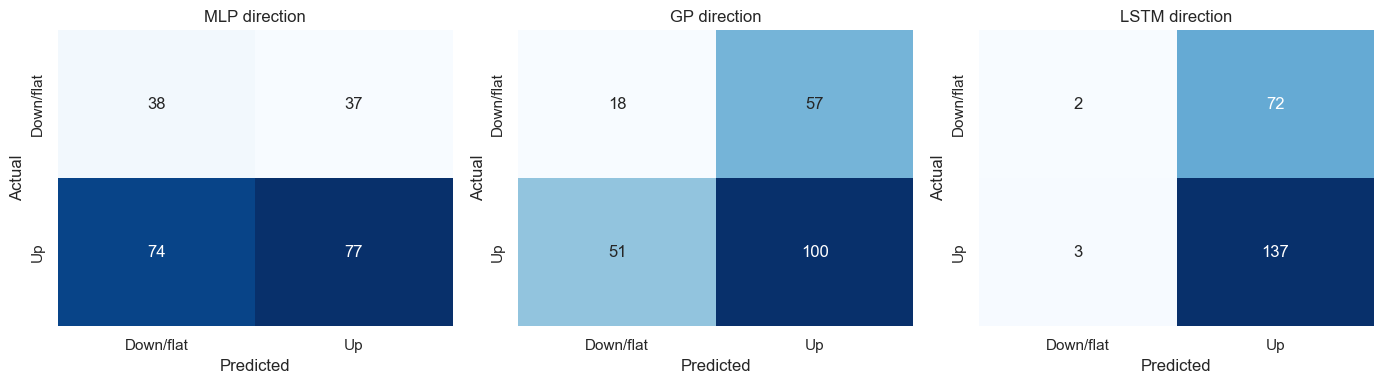

In [14]:
direction_data = make_supervised_panel(target='direction', predictors=ASSIGNED_FEATURES)

# Training-only distance-correlation screen for compact direction models.
dcorr_rows = []
for col in direction_data['feature_cols']:
    dcorr_rows.append({
        'feature': col,
        'distance_corr': dcor.distance_correlation(direction_data['X_train_all'][col].to_numpy(), direction_data['y_train'].to_numpy()),
    })
dir_ranking = pd.DataFrame(dcorr_rows).sort_values('distance_corr', ascending=False).reset_index(drop=True)
dir_features = dir_ranking.head(10)['feature'].tolist()

X_train_dir = direction_data['X_train_all'][dir_features]
X_test_dir = direction_data['X_test_all'][dir_features]
y_train_dir = direction_data['y_train']
y_test_dir = direction_data['y_test']

classification_rows = []
majority_score = np.repeat(int(y_train_dir.mode().iloc[0]), len(y_test_dir))
row, pred_majority = classification_metrics('Direction majority class', y_test_dir, majority_score)
classification_rows.append(row)
prev_score = direction_data['test']['TARGET_lag1'].astype(int).to_numpy()
row, pred_prev = classification_metrics('Previous-month direction', y_test_dir, prev_score)
classification_rows.append(row)

mlp_clf = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(max_iter=500, shuffle=False, random_state=RANDOM_STATE)),
    ]),
    param_grid={
        'mlp__hidden_layer_sizes': [(8,), (16,), (16, 8)],
        'mlp__activation': ['relu', 'tanh'],
        'mlp__alpha': [1e-2, 1e-1],
    },
    cv=TimeSeriesSplit(n_splits=3),
    scoring='balanced_accuracy',
    n_jobs=1,
    refit=True,
)
mlp_clf.fit(X_train_dir, y_train_dir)
row, pred_mlp_dir = classification_metrics('Direction MLPClassifier', y_test_dir, estimator_scores(mlp_clf.best_estimator_, X_test_dir))
classification_rows.append(row)

gp_clf = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('gp', GaussianProcessClassifier(random_state=RANDOM_STATE, optimizer=None, max_iter_predict=100)),
    ]),
    param_grid={'gp__kernel': [RBF(), Matern(nu=1.5), RationalQuadratic()]},
    cv=TimeSeriesSplit(n_splits=3),
    scoring='balanced_accuracy',
    n_jobs=1,
    refit=True,
)
gp_clf.fit(X_train_dir, y_train_dir)
row, pred_gp_dir = classification_metrics('Direction GaussianProcessClassifier', y_test_dir, estimator_scores(gp_clf.best_estimator_, X_test_dir))
classification_rows.append(row)

# Small LSTM classifier on the same direction feature set.
def fit_lstm_classifier(X_train_df, y_train_ser, X_test_df, y_test_ser, timesteps=12, units=16, dropout=0.2):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_df)
    X_test_scaled = scaler.transform(X_test_df)
    X_seq, y_seq = make_lstm_regression_sequences(X_train_scaled, y_train_ser, timesteps)
    X_test_seq, y_test_seq = make_lstm_regression_sequences(X_test_scaled, y_test_ser, timesteps)
    val_start = int(0.85 * len(X_seq))

    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential([
        LSTM(units, input_shape=(timesteps, X_train_df.shape[1]), dropout=dropout, recurrent_dropout=dropout),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    model.fit(X_seq[:val_start], y_seq[:val_start], validation_data=(X_seq[val_start:], y_seq[val_start:]),
              epochs=60, batch_size=16, shuffle=False, verbose=0, callbacks=[early_stop])
    scores = model.predict(X_test_seq, verbose=0).reshape(-1)
    return scores, y_test_seq.astype(int)

lstm_dir_scores, lstm_dir_y = fit_lstm_classifier(X_train_dir, y_train_dir, X_test_dir, y_test_dir)
row, pred_lstm_dir = classification_metrics('Direction LSTMClassifier', lstm_dir_y, lstm_dir_scores)
classification_rows.append(row)

direction_table = pd.DataFrame(classification_rows).set_index('model').sort_values('Balanced accuracy %', ascending=False)
display(direction_table.round(4))
print('Best direction MLP params:', mlp_clf.best_params_)
print('Best direction GP params:', gp_clf.best_params_)
print('Direction features:', dir_features)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, title, y_true, y_pred in [
    (axes[0], 'MLP direction', y_test_dir, pred_mlp_dir),
    (axes[1], 'GP direction', y_test_dir, pred_gp_dir),
    (axes[2], 'LSTM direction', lstm_dir_y, pred_lstm_dir),
]:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Down/flat', 'Up'], yticklabels=['Down/flat', 'Up'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


### 2.9 Sensitivity Analysis

,feature,importance,std
4,TARGET_lag12,1.521000e-05,0.000017
13,svar_lag6,1.469000e-05,0.000009
1,TARGET_lag2,1.430000e-05,0.000015
19,ntis_lag12,8.800000e-06,0.000013
2,TARGET_lag3,8.070000e-06,0.000015
17,ntis_lag3,7.590000e-06,0.000011
3,TARGET_lag6,6.860000e-06,0.000015
14,svar_lag12,6.700000e-06,0.000008
18,ntis_lag6,6.090000e-06,0.000011
16,ntis_lag2,5.870000e-06,0.000011


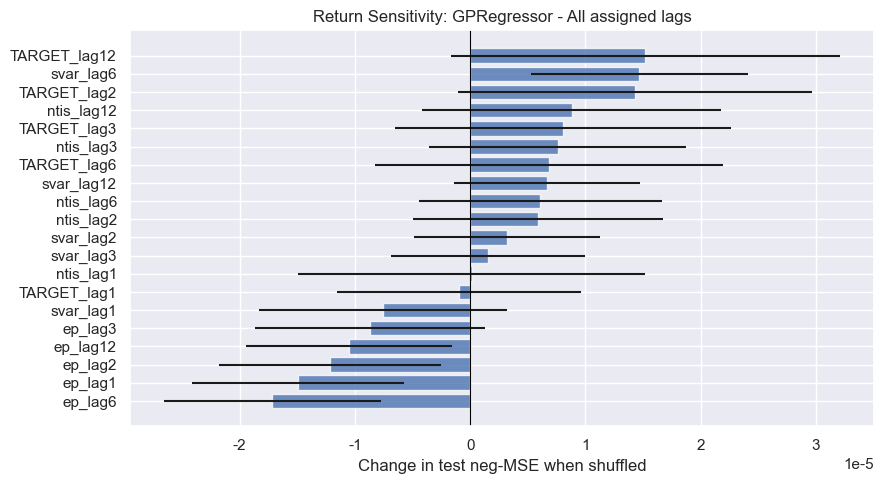

In [15]:
# Model-agnostic sensitivity for the best return model that exposes sklearn predict().
# If the best model is an LSTM, use the best GP instead for a stable sklearn-based diagnostic.
best_sklearn_rows = mlp_results + gp_results
best_sklearn_row = max(best_sklearn_rows, key=lambda r: r['Outperform mean %'])
best_sklearn_name = best_sklearn_row['model']
best_sklearn_fs = best_sklearn_name.split(' - ', 1)[1]
best_cols = feature_sets[best_sklearn_fs]

if best_sklearn_name.startswith('MLP'):
    # Refit the best MLP spec for permutation importance.
    best_params = best_sklearn_row['Best params']
    sens_est = TransformedTargetRegressor(
        regressor=Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPRegressor(
                solver='lbfgs', max_iter=1500, random_state=RANDOM_STATE,
                hidden_layer_sizes=best_params['regressor__mlp__hidden_layer_sizes'],
                activation=best_params['regressor__mlp__activation'],
                alpha=best_params['regressor__mlp__alpha'],
            )),
        ]),
        transformer=StandardScaler(),
    )
else:
    sens_est = gp_best_estimators[best_sklearn_fs]

X_sens_train = return_data['X_train_all'][best_cols]
y_sens_train = return_data['y_train']
X_sens_test = return_data['X_test_all'][best_cols]
y_sens_test = return_data['y_test']

if best_sklearn_name.startswith('MLP'):
    sens_est.fit(X_sens_train, y_sens_train)

perm = permutation_importance(
    sens_est,
    X_sens_test,
    y_sens_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring='neg_mean_squared_error',
)
sensitivity = pd.DataFrame({
    'feature': best_cols,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)

display(sensitivity.round(8))

fig, ax = plt.subplots(figsize=(9, 5))
plot_sens = sensitivity.sort_values('importance')
ax.barh(plot_sens['feature'], plot_sens['importance'], xerr=plot_sens['std'], alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_title(f'Return Sensitivity: {best_sklearn_name}')
ax.set_xlabel('Change in test neg-MSE when shuffled')
plt.tight_layout()
plt.show()


### 2.10 Part 2 Notes for the Report

Use the generated tables to discuss both target choice and model comparison. The main return-regression benchmark is the historical mean return, because monthly equity returns are low-signal and hard to beat. Direction classification is useful as a decision-oriented target, but it should be compared against majority-class and previous-month-direction baselines. Weak or negative out-of-sample performance should be interpreted as evidence of limited stable predictability, not as a coding failure.


### 2.11 Latest Local Run Summary

Executed locally with the `Python (General ML/Finance)` kernel on 2026-05-13 after revising Q2 to make monthly log-return regression the main target. The data source is `goyal-welch2022Monthly.csv`, filtered to `1927-01-01` through `2021-12-01`. After lag construction, the return forecasting sample runs from `1928-02-01` to `2021-12-01`, with an 80/20 chronological split: training through `2003-02-01`, testing from `2003-03-01` onward.

Main return-regression leaderboard from the verification run:

| Model | Feature set | Test MSE | Interpretation |
|---|---|---:|---|
| Historical mean return | benchmark | 0.001711 | Best overall benchmark; hard to beat |
| GPRegressor | All assigned lags | 0.001740 | Closest ML model; stable but slightly worse than mean |
| LSTMRegressor | Selected robust | 0.001778 | Close, but not robustly better than mean |
| LSTMRegressor | Selected top 6 | 0.001953 | Worse than mean |
| GPRegressor | Selected robust | 0.002002 | Worse than mean |
| GPRegressor | Selected top 6 | 0.002319 | Worse than mean |
| MLPRegressor | Selected top 6 | 0.004790 | Clear overfitting/instability |
| MLPRegressor | Selected robust | 0.007030 | Clear overfitting/instability |
| MLPRegressor | All assigned lags | 0.008016 | Clear overfitting/instability |

Training-only CV permutation importance selected the parsimonious feature set `ntis_lag1`, `ep_lag3`, `ntis_lag2`, `svar_lag3`, `ep_lag12`, `ntis_lag3`. The robust set adds `TARGET_lag6`, `TARGET_lag12`, `ntis_lag6`, and `TARGET_lag2`. This supports a useful report narrative: the assigned variables are not all equally useful, `ntis` appears repeatedly among selected lags, but the signal is too weak to reliably beat the historical mean.

The direction-classification check remains secondary. It also does not provide strong evidence of exploitable predictability: raw accuracy can look high because up months dominate, while balanced metrics and naive baselines are much harder to beat. This is why the report should emphasize balanced accuracy, ROC-AUC, and comparison with previous-month direction rather than raw accuracy alone.

Overall conclusion for Q2: price levels should not be the main target; return regression is assignment-aligned but very hard to improve against the historical mean; direction classification is interpretable but also weak once compared with naive baselines. The revised implementation now has a stronger grading narrative because it shows leakage-safe preprocessing, historical-mean benchmarking, feature selection, tuned NN/GP/LSTM models, visual diagnostics, and sensitivity analysis.


---
## 3. Problem 3: ARMA-GARCH Baseline (20%)

**Objective:** Fit an ARMA-GARCH model on the same `SP` log-return series as a
classical time-series benchmark.  Compare volatility forecasts and return forecasts
against the ML models from Problem 2.

*Uses the `gw_model` dataframe prepared in Section 2.1.*


---
### 3.1 – 3.x  ARMA-GARCH Implementation (to be implemented)

*Exercise cells for ADF testing, ARMA order selection, GARCH fitting,*
*volatility forecasting, and performance benchmarking will go here.*


---
## 4. Lessons Learned (5%)

*[To be filled in after completing all exercises.]*

Consider addressing:
- What causal relationships were most surprising in the asset network?
- How did ML models compare against the ARMA-GARCH baseline?
- What data or modelling challenges did you encounter?


---
## 5. Author Contributions

| Author | Problems worked on | Specific contributions |
|--------|-------------------|------------------------|
| Lucas Salamanca | | |
| Nicolas Koutalakis | | |
| Lorenzo | | |
